[TRAIN][POOLED-LR] n=400 pos=105 (26.25%)
[TRAIN][POOLED-LR] n=450 pos=106 (23.56%)
[TRAIN][POOLED-LR] n=500 pos=110 (22.00%)
[TRAIN][POOLED-LR] n=550 pos=123 (22.36%)
[TRAIN][POOLED-LR] n=600 pos=123 (20.50%)
[TRAIN][POOLED-LR] n=650 pos=130 (20.00%)
[TRAIN][POOLED-LR] n=700 pos=130 (18.57%)
[TRAIN][POOLED-LR] n=750 pos=135 (18.00%)
[TRAIN][POOLED-LR] n=800 pos=137 (17.12%)
[TRAIN][POOLED-LR] n=850 pos=137 (16.12%)
[TRAIN][POOLED-LR] n=900 pos=137 (15.22%)
[TRAIN][POOLED-LR] n=950 pos=137 (14.42%)
[TRAIN][POOLED-LR] n=1000 pos=147 (14.70%)
[TRAIN][POOLED-LR] n=1050 pos=166 (15.81%)
[TRAIN][POOLED-LR] n=1100 pos=169 (15.36%)
[TRAIN][POOLED-LR] n=1150 pos=184 (16.00%)
[TRAIN][POOLED-LR] n=1200 pos=184 (15.33%)
[TRAIN][POOLED-LR] n=1250 pos=189 (15.12%)
[TRAIN][POOLED-LR] n=1300 pos=194 (14.92%)
[TRAIN][POOLED-LR] n=1350 pos=209 (15.48%)
[TRAIN][POOLED-LR] n=1400 pos=247 (17.64%)
[TRAIN][POOLED-LR] n=1450 pos=284 (19.59%)
[TRAIN][POOLED-LR] n=1500 pos=291 (19.40%)
[TRAIN][POOLED-LR] n=15

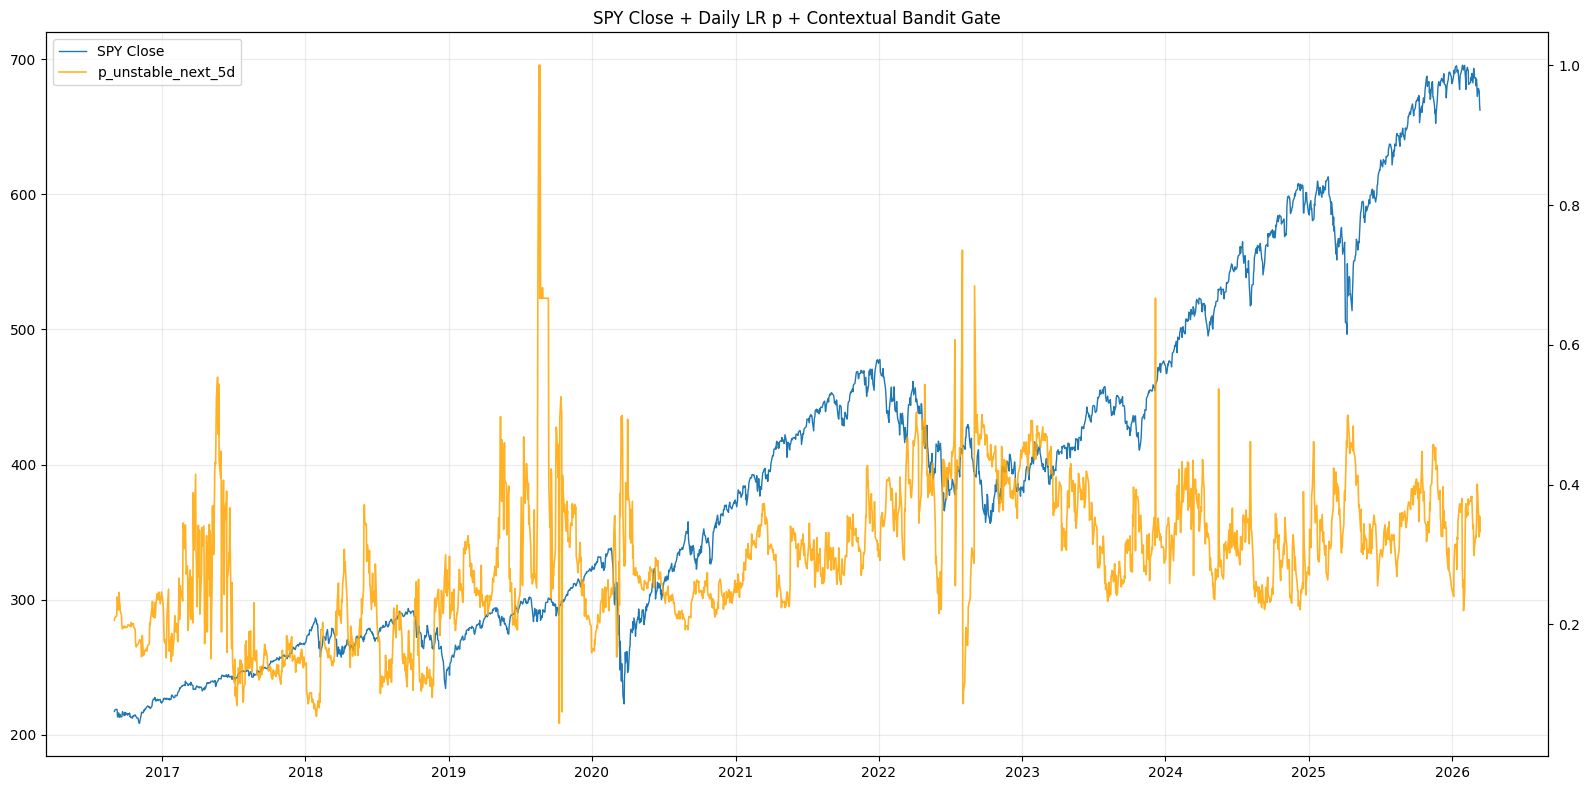

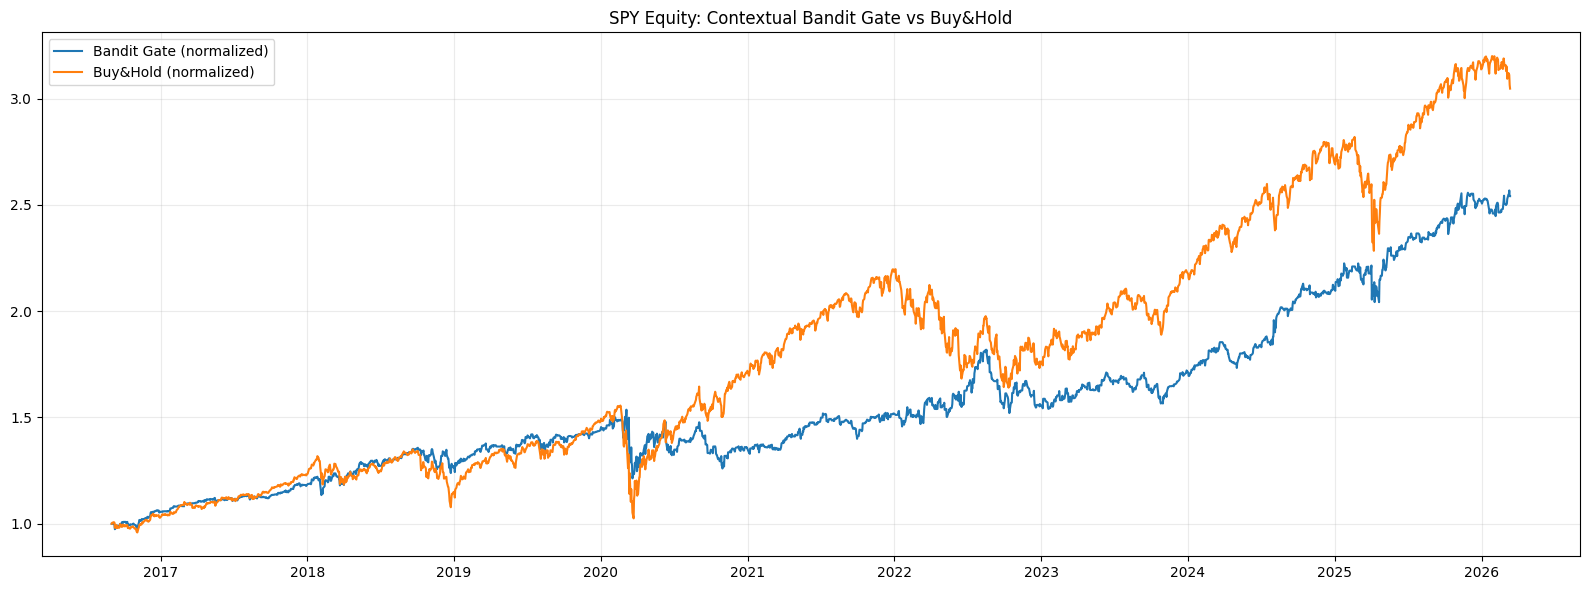

[SPY] out_days=2395 trades=1226 final_eq=222562.15


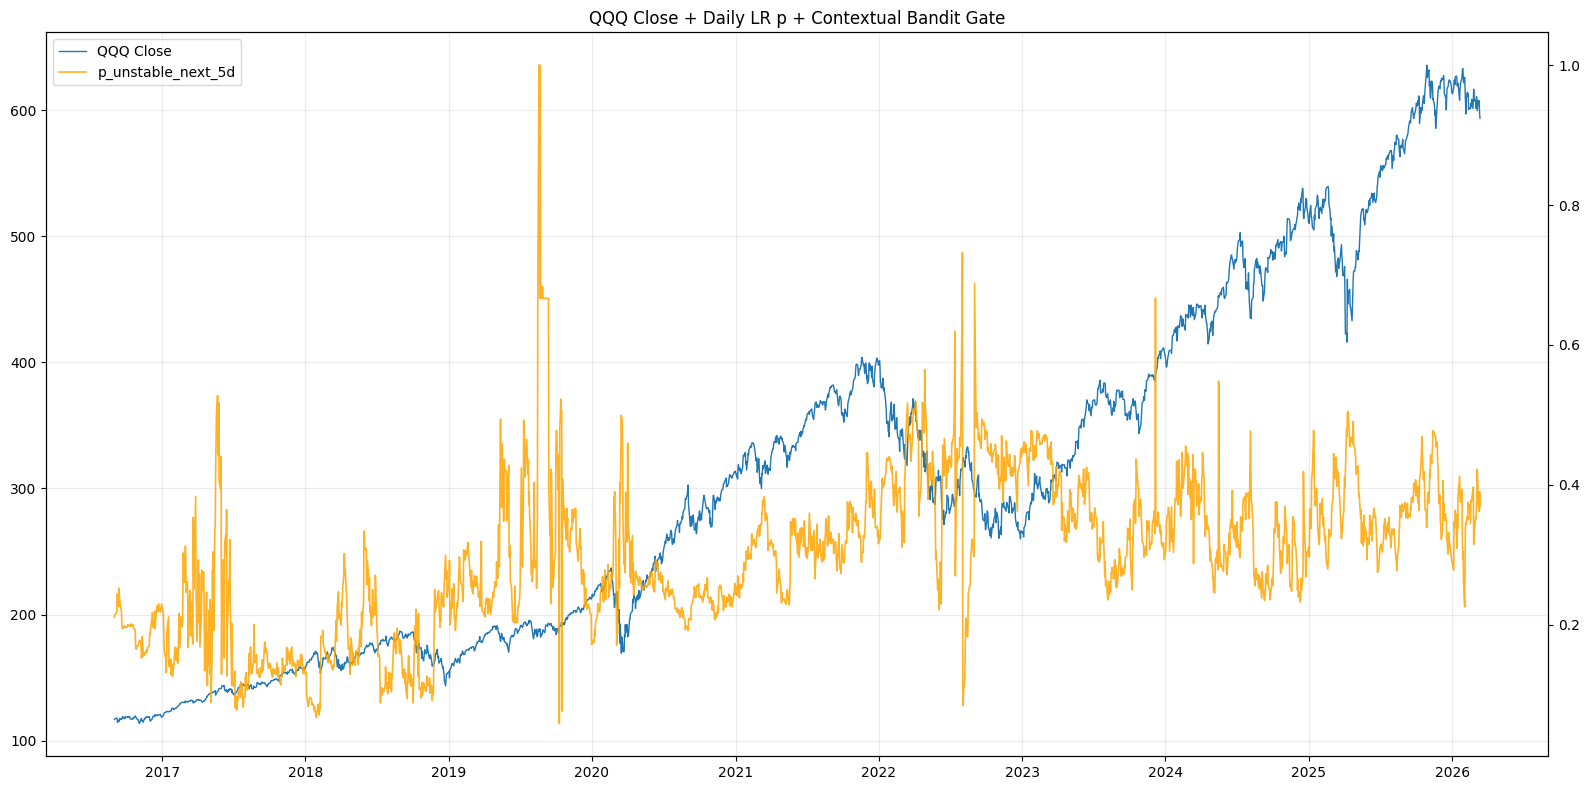

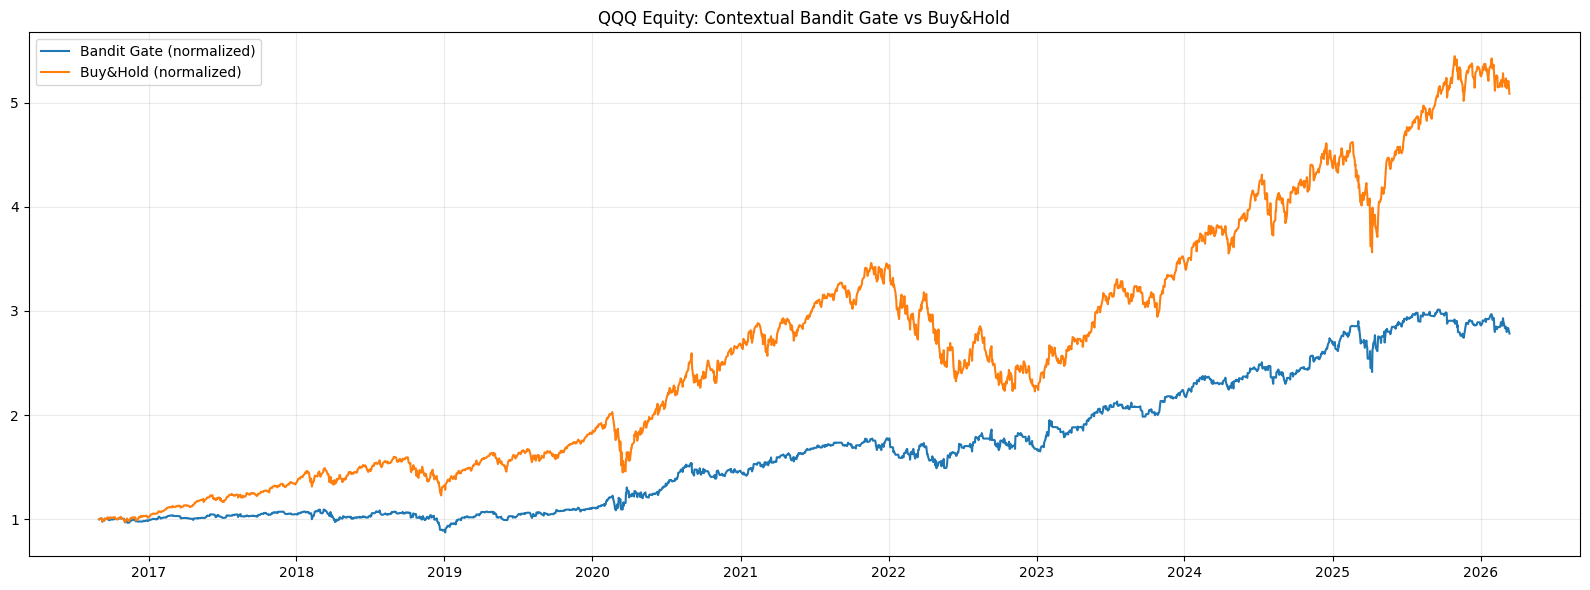

[QQQ] out_days=2395 trades=928 final_eq=258317.40
[LABELS][POOLED] n=5416 pos=1388 (25.63%)
[MODEL][POOLED-LR] trained=yes trained_n=5400
[SPY] total_daily_bsp=773
[QQQ] total_daily_bsp=815

===== TOP 50 FEATURE IMPORTANCE =====
            feature  coef_mean  abs_coef_mean     direction  coef_fold_0  coef_fold_1  coef_fold_2
      spgsci_vol_20  -1.629964       1.629964   more_stable    -2.578555    -2.358856     0.047520
         vxn_vol_40  -1.382118       1.382118   more_stable    -1.793791    -1.921288    -0.431276
    rvx_above_ma_20   1.364585       1.364585 more_unstable     1.312545     1.091092     1.690116
     yc_10y5y_level  -1.268626       1.268626   more_stable    -2.367449    -1.656166     0.217736
      spgsci_ret_10   1.253622       1.253622 more_unstable     1.939334     0.713541     1.107992
        vxn_slope40   1.166438       1.166438 more_unstable     1.257423     1.140460     1.101430
          xau_level  -1.152974       1.152974   more_stable    -0.536441    -1

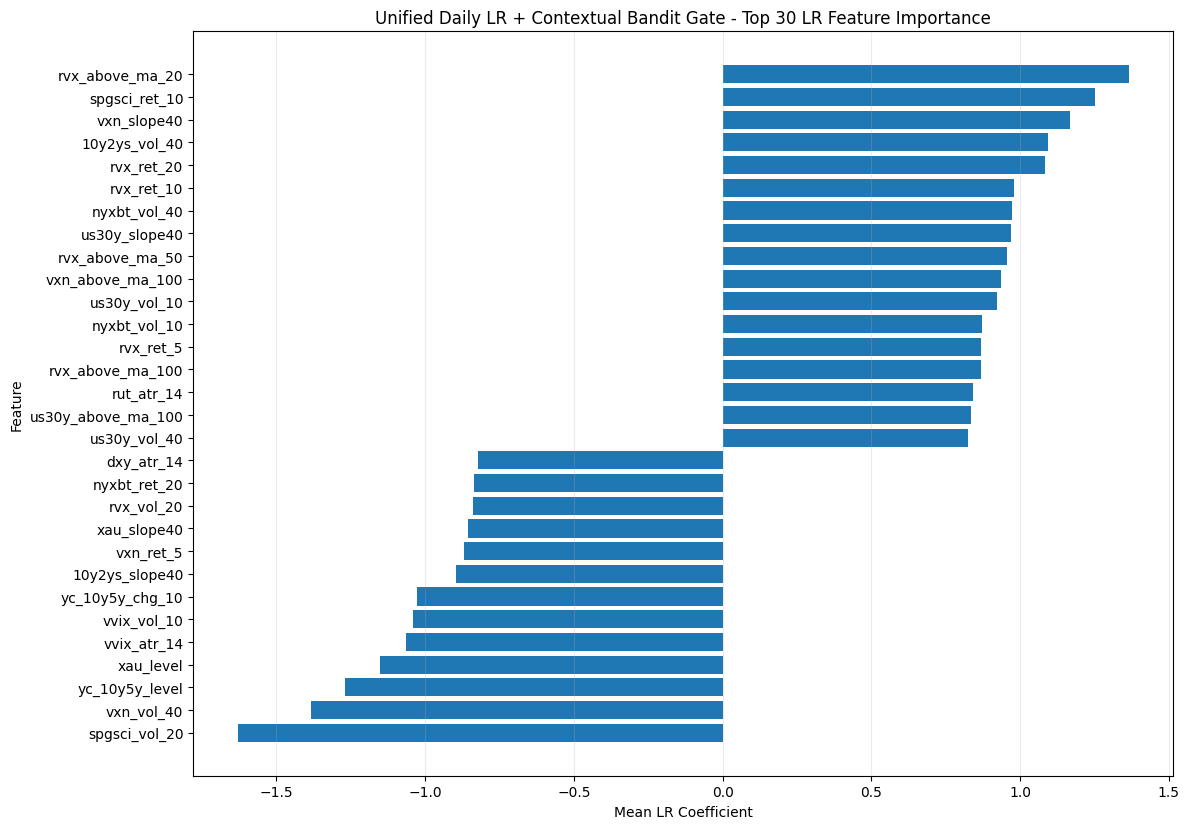

In [2]:
# ============================================================
# UNIFIED DAILY "RISK / INSTABILITY" P (ONE MEANING)
# + DAILY CHAN BSP STRUCTURE FEATURES
# + POOLED TRAINING ON SPY + QQQ (instrument_id)
# + CONTEXTUAL BANDIT 3-STATE GATE: HOLD / FREE / RISK_OFF
#
# Recommended architecture:
#   daily features + macro + daily Chan BSP
#       -> pooled LR instability model
#       -> p_unstable
#   [p_unstable + daily state + position/equity context]
#       -> LinUCB contextual bandit
#       -> HOLD / FREE / RISK_OFF
#
# Notes:
# - HOLD     : ensure long
# - RISK_OFF : ensure flat
# - FREE     : placeholder reward proxy for now
#              (recommended later: replace with actual 5m-engine next-day pnl)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Any, List, Optional, Tuple
from dataclasses import dataclass

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# ---- your Chan imports
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime


# ============================================================
# 1) CSV loader + kline features
# ============================================================
def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


def load_daily_csv(daily_csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(daily_csv_path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col = _pick_col(df, ["open", "Open", "o", "O"])
    high_col = _pick_col(df, ["high", "High", "h", "H"])
    low_col = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    if open_col is None or close_col is None:
        raise ValueError(f"CSV must contain open and close columns: {daily_csv_path}")
    if high_col is None:
        high_col = close_col
    if low_col is None:
        low_col = close_col

    vol_col = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    df["_open"] = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"] = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"] = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"] = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["ts_norm"] = df["timestamp"].dt.normalize()
    return df


def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)


KLINE_KEYS = [
    "ret1", "ret_5", "ret_10", "ret_20", "ret_40",
    "vol_5", "vol_10", "vol_20", "vol_40",
    "atr_14", "range_over_atr", "close_pos", "gap",
    "above_ma_20", "above_ma_50", "above_ma_100",
    "slope40",
]


def compute_kline_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy().sort_values("timestamp").reset_index(drop=True)

    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h - l).abs(), (h - prev_c).abs(), (l - prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range_over_atr"] = _safe_div((h - l).abs(), d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)

    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t * t).sum()
        return 0.0 if den <= 0 else float((t * x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d


def make_kline_dict(kline_row: pd.Series, prefix: str) -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = kline_row[k] if k in kline_row.index else 0.0
        out[f"{prefix}{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# 2) Macro features loader (daily)
# ============================================================
def load_macro_features_from_folder(folder: str, files: Dict[str, str], start: str) -> pd.DataFrame:
    out = None
    for pref, fn in files.items():
        path = os.path.join(folder, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Macro file not found: {path}")

        dfm = load_daily_csv(path)
        dfm = dfm[dfm["timestamp"] >= pd.to_datetime(start)].copy().reset_index(drop=True)
        dfm_feat = compute_kline_features(dfm)

        dfm_feat[f"{pref}level"] = dfm_feat["_close"].astype(float)

        cols = ["ts_norm", f"{pref}level"] + KLINE_KEYS
        dfm_feat = dfm_feat[cols].copy()

        rename = {k: f"{pref}{k}" for k in KLINE_KEYS}
        dfm_feat = dfm_feat.rename(columns=rename)

        out = dfm_feat.copy() if out is None else out.merge(dfm_feat, on="ts_norm", how="outer")

    if out is None:
        out = pd.DataFrame(columns=["ts_norm"])

    if ("us10y_level" in out.columns) and ("us5y_level" in out.columns):
        out["yc_10y5y_level"] = out["us10y_level"] - out["us5y_level"]

        prev = out["yc_10y5y_level"].shift(1)
        out["yc_10y5y_ret1"] = (
            _safe_div(out["yc_10y5y_level"], prev) - 1.0
        ).replace([np.inf, -np.inf], np.nan).fillna(0.0)

        for w in [5, 10, 20, 40]:
            out[f"yc_10y5y_chg_{w}"] = (
                out["yc_10y5y_level"] - out["yc_10y5y_level"].shift(w)
            ).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return out.sort_values("ts_norm").reset_index(drop=True)


# ============================================================
# 3) DAILY CHAN BSP extraction + structure features
# ============================================================
def to_ctime(ts) -> CTime:
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)


def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW: float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct,
        "timestamp": ct,
        "datetime": ct,
        "open": float(o),
        "high": float(h),
        "low": float(l),
        "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu


def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr


def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []


def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir})
            cur_dir = d
            cur_end = bsps[i]
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir})
    return ends


def regime_for_day(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]
        b = ends[k + 1]
        if (day_norm >= a["end_ts"]) and (day_norm <= b["end_ts"]):
            if a["end_dir"] == "buy" and b["end_dir"] == "sell":
                return "up"
            if a["end_dir"] == "sell" and b["end_dir"] == "buy":
                return "down"
    return "unknown"


def bsp_context_features(bsp_rows: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "bsp_has": 0.0,
            "bsp_last_buy": 0.0,
            "bsp_last_sell": 0.0,
            "bsp_days_since_last": 999.0,
            "bsp_density": 0.0,
            "bsp_density_buy": 0.0,
            "bsp_density_sell": 0.0,
            "bsp_imbalance": 0.0,
            "bsp_alternations_20": 0.0,
        }

    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    last20 = recent[-20:] if len(recent) > 0 else []
    alt = 0
    for i in range(1, len(last20)):
        if str(last20[i]["direction"]).lower() != str(last20[i - 1]["direction"]).lower():
            alt += 1

    return {
        "bsp_has": 1.0,
        "bsp_last_buy": 1.0 if last_dir == "buy" else 0.0,
        "bsp_last_sell": 1.0 if last_dir == "sell" else 0.0,
        "bsp_days_since_last": days_since_last,
        "bsp_density": float(len(recent)),
        "bsp_density_buy": float(buy),
        "bsp_density_sell": float(sell),
        "bsp_imbalance": float((sell - buy) / tot),
        "bsp_alternations_20": float(alt),
    }


# ============================================================
# 4) Unified LABEL = future instability
# ============================================================
def label_instability_for_day(
    df_feat: pd.DataFrame,
    day_idx: int,
    N: int,
    dd_thresh: float = -0.03,
    rv_quantile: float = 0.80,
    rv_ref_lookback: int = 252,
) -> Optional[int]:
    if N <= 0 or day_idx + N >= len(df_feat):
        return None

    c0 = float(df_feat.loc[day_idx, "_close"])
    if not (np.isfinite(c0) and c0 > 0):
        return None

    fut = df_feat.loc[day_idx + 1:day_idx + N].copy()
    if fut.empty:
        return None

    min_low = float(fut["_low"].min())
    dd = (min_low / c0) - 1.0

    fut_rets = fut["ret1"].astype(float).to_numpy()
    rv = float(np.std(fut_rets)) if len(fut_rets) > 1 else 0.0

    if day_idx < rv_ref_lookback:
        return 1 if dd <= dd_thresh else 0

    past = df_feat.loc[day_idx - rv_ref_lookback:day_idx].copy()
    past_rv_proxy = past["ret1"].rolling(N).std().dropna()
    if len(past_rv_proxy) < 50:
        return 1 if dd <= dd_thresh else 0

    rv_cut = float(past_rv_proxy.quantile(rv_quantile))
    unstable = (dd <= dd_thresh) or (rv >= rv_cut)
    return 1 if unstable else 0


# ============================================================
# 5) Model (LR + calibration)
# ============================================================
def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1,
        )),
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base


def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]


# ============================================================
# 6) Feature builder = daily kline + macro + DAILY CHAN BSP + instrument_id
# ============================================================
def make_daily_features_unified(
    asset_row: pd.Series,
    macro_row: Optional[pd.Series],
    instrument_id: int,
    bsp_rows_up_to_day: List[Dict[str, Any]],
    regime: str,
) -> Dict[str, float]:
    feats: Dict[str, float] = {}

    feats.update(make_kline_dict(asset_row, prefix="d_"))

    if macro_row is not None:
        for col in macro_row.index:
            if col == "ts_norm":
                continue
            val = macro_row[col]
            feats[str(col)] = float(val) if np.isfinite(val) else 0.0

    ts = pd.to_datetime(asset_row["timestamp"])
    feats.update(bsp_context_features(bsp_rows_up_to_day, ts, window_days=60))

    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0

    feats["instrument_id"] = float(instrument_id)
    return feats


# ============================================================
# 6B) Bandit state builder
# ============================================================
def make_bandit_state_dict(
    base_feat: Dict[str, float],
    p_unstable: float,
    current_pos: int,
    current_gate: str,
    equity_rel: float,
    dd_rel: float,
    symbol: str,
) -> Dict[str, float]:
    s = dict(base_feat)

    s["p_unstable"] = float(p_unstable) if np.isfinite(p_unstable) else 0.5

    s["cur_pos"] = float(current_pos)
    s["cur_gate_hold"] = 1.0 if current_gate == "HOLD" else 0.0
    s["cur_gate_free"] = 1.0 if current_gate == "FREE" else 0.0
    s["cur_gate_risk_off"] = 1.0 if current_gate == "RISK_OFF" else 0.0
    s["equity_rel"] = float(equity_rel)
    s["drawdown_rel"] = float(dd_rel)

    s["is_spy"] = 1.0 if str(symbol).upper() == "SPY" else 0.0
    s["is_qqq"] = 1.0 if str(symbol).upper() == "QQQ" else 0.0

    return s


# ============================================================
# 6C) Reward function for bandit
# ============================================================
def compute_bandit_reward_one_day(
    action_name: str,
    next_open: float,
    next_close: float,
    fee_pct: float = 0.0,
    free_reward_proxy_scale: float = 0.5,
) -> float:
    if not (np.isfinite(next_open) and np.isfinite(next_close) and next_open > 0):
        return 0.0

    gross_ret = (float(next_close) / float(next_open)) - 1.0

    if action_name == "HOLD":
        return gross_ret - float(fee_pct)
    elif action_name == "RISK_OFF":
        return 0.0
    else:
        # Placeholder until you plug in actual 5m-engine next-day reward
        return free_reward_proxy_scale * gross_ret


# ============================================================
# 7) Contextual bandit
# ============================================================
class BanditAction:
    HOLD = 0
    FREE = 1
    RISK_OFF = 2


ACTION_TO_NAME = {
    BanditAction.HOLD: "HOLD",
    BanditAction.FREE: "FREE",
    BanditAction.RISK_OFF: "RISK_OFF",
}
NAME_TO_ACTION = {v: k for k, v in ACTION_TO_NAME.items()}


class LinUCBBandit:
    """
    3-action contextual bandit using LinUCB.
    reward_hat = theta_a^T x + alpha * sqrt(x^T A_a^{-1} x)
    """
    def __init__(self, n_actions: int, n_features: int, alpha: float = 0.75, l2: float = 1.0):
        self.n_actions = int(n_actions)
        self.n_features = int(n_features)
        self.alpha = float(alpha)
        self.l2 = float(l2)

        self.A = [np.eye(self.n_features, dtype=float) * self.l2 for _ in range(self.n_actions)]
        self.b = [np.zeros(self.n_features, dtype=float) for _ in range(self.n_actions)]

    def select_action(self, x: np.ndarray) -> int:
        x = np.asarray(x, dtype=float).reshape(-1)
        scores = []
        for a in range(self.n_actions):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            mean = float(theta @ x)
            bonus = self.alpha * float(np.sqrt(x @ A_inv @ x))
            scores.append(mean + bonus)
        return int(np.argmax(scores))

    def update(self, action: int, x: np.ndarray, reward: float):
        x = np.asarray(x, dtype=float).reshape(-1)
        a = int(action)
        r = float(reward)

        self.A[a] += np.outer(x, x)
        self.b[a] += r * x


@dataclass
class OnlineState:
    model: Optional[Any] = None
    new_labels: int = 0
    trained_n: int = 0


# ============================================================
# 8) Main pooled runner: SPY+QQQ daily Chan BSP-aware p + bandit gate
# ============================================================
def run_unified_daily_bandit_gate_with_daily_chan_bsp_pooled(
    asset_csvs: Dict[str, str],
    daily_start: str = "2015-06-01",

    plot_start: str = "2016-09-01",
    plot_end: str = "2024-12-31",
    output_start: str = "2016-09-01",
    output_end: str = "2024-12-31",

    N: int = 5,
    dd_thresh: float = -0.03,
    rv_quantile: float = 0.80,
    rv_ref_lookback: int = 252,

    min_labeled_days_to_train: int = 400,
    retrain_every_new_labels: int = 50,

    # bandit
    bandit_alpha: float = 0.75,
    bandit_l2: float = 1.0,
    free_reward_proxy_scale: float = 0.5,

    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,
    trade_at: str = "next_open",
    start_in_market: bool = True,

    macro_files: Optional[Dict[str, str]] = None,
    daily_chan_max_klines: int = 800,
    verbose: bool = True,
):
    if macro_files is None:
        macro_files = {
            "vix_": "VIX.csv",
            "dxy_": "DXY.csv",
            "us10y_": "US10Y.csv",
            "us30y_": "US30Y.csv",
            "xau_": "XAU.csv",
            "nyxbt_": "NYXBT.csv",
        }

    first_path = list(asset_csvs.values())[0]
    folder = os.path.dirname(os.path.abspath(first_path))
    macro_feat = load_macro_features_from_folder(folder, macro_files, start=daily_start)
    macro_cols = [c for c in macro_feat.columns if c != "ts_norm"]

    inst_map = {sym: i for i, sym in enumerate(sorted(asset_csvs.keys()))}

    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    # load assets and compute features
    assets = []
    for sym, path in asset_csvs.items():
        df0 = load_daily_csv(path)
        df0 = df0[df0["timestamp"] >= pd.to_datetime(daily_start)].copy().reset_index(drop=True)
        df_feat = compute_kline_features(df0)
        df_feat = df_feat.merge(macro_feat, on="ts_norm", how="left").sort_values("timestamp").reset_index(drop=True)
        df_feat["symbol"] = sym
        df_feat["instrument_id"] = inst_map[sym]
        assets.append(df_feat)

    day_set = set()
    for df in assets:
        day_set |= set(pd.to_datetime(df["timestamp"]).dt.normalize().tolist())
    all_days = sorted(day_set)

    idx_map = {}
    for df in assets:
        sym = df["symbol"].iloc[0]
        idx_map[sym] = {pd.to_datetime(df.loc[i, "timestamp"]).normalize(): i for i in range(len(df))}

    st = OnlineState()
    X_all, y_all = [], []
    pending = {sym: [] for sym in asset_csvs.keys()}

    chan_objs = {}
    bsp_rows = {sym: [] for sym in asset_csvs.keys()}
    seen_bsp = {sym: set() for sym in asset_csvs.keys()}
    regime_series = {sym: np.array(["unknown"] * len(df), dtype=object) for sym, df in [(d["symbol"].iloc[0], d) for d in assets]}
    p_pred = {sym: np.full(len(df), np.nan, dtype=float) for sym, df in [(d["symbol"].iloc[0], d) for d in assets]}
    y_label = {}

    for df in assets:
        sym = df["symbol"].iloc[0]
        chan_objs[sym] = SlidingWindowChan(
            code=sym,
            begin_time=None,
            end_time=None,
            data_src=getattr(DATA_SRC, "CSV", "CSV"),
            lv_list=[KL_TYPE.K_DAY],
            config=config,
            autype=AUTYPE.QFQ,
            max_klines=int(daily_chan_max_klines),
        )

        y = np.array([np.nan] * len(df), dtype=float)
        for i in range(len(df)):
            lab = label_instability_for_day(df, i, N, dd_thresh, rv_quantile, rv_ref_lookback)
            y[i] = np.nan if lab is None else float(lab)
        y_label[sym] = y

    def maybe_train():
        if len(y_all) < int(min_labeled_days_to_train):
            return
        if st.model is None or st.new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_all, dtype=int)
            if len(np.unique(y)) < 2:
                return
            st.model = fit_prob_model_dicts(X_all, y)
            st.trained_n = len(y)
            st.new_labels = 0
            if verbose:
                print(f"[TRAIN][POOLED-LR] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")

    # online pooled LR training
    for day in all_days:
        for df in assets:
            sym = df["symbol"].iloc[0]
            if day not in idx_map[sym]:
                continue
            i = idx_map[sym][day]
            ts = pd.to_datetime(df.loc[i, "timestamp"])

            chan = chan_objs[sym]
            chan.process_new_kline(build_klu(
                ts=ts,
                o=float(df.loc[i, "_open"]),
                h=float(df.loc[i, "_high"]),
                l=float(df.loc[i, "_low"]),
                c=float(df.loc[i, "_close"]),
                v=float(df.loc[i, "_vol"]) if "_vol" in df.columns else 0.0,
            ))

            new_bsp = extract_bsp_rows_from_chan(chan)
            if new_bsp:
                for r0 in new_bsp:
                    r = normalize_bsp_row(dict(r0))
                    r.setdefault("timestamp", ts)
                    key = (pd.to_datetime(r["timestamp"]).strftime("%Y-%m-%d"), r["direction"], r.get("bsp_type", "?"))
                    if key in seen_bsp[sym]:
                        continue
                    seen_bsp[sym].add(key)
                    bsp_rows[sym].append(r)

            ends = compute_chain_endpoints(bsp_rows[sym])
            rg = regime_for_day(day, ends)
            regime_series[sym][i] = rg

            if st.model is not None:
                macro_row = df.loc[i, macro_cols] if len(macro_cols) else None
                past_bsp = [r for r in bsp_rows[sym] if pd.to_datetime(r["timestamp"]) <= ts]
                feat_i = make_daily_features_unified(
                    asset_row=df.loc[i],
                    macro_row=macro_row,
                    instrument_id=int(df.loc[i, "instrument_id"]),
                    bsp_rows_up_to_day=past_bsp,
                    regime=rg,
                )
                p_pred[sym][i] = float(predict_prob(st.model, [feat_i])[0])

            pending[sym].append(i)
            while pending[sym] and i >= pending[sym][0] + int(N):
                j = pending[sym].pop(0)
                lab = y_label[sym][j]
                if not np.isfinite(lab):
                    continue

                tsj = pd.to_datetime(df.loc[j, "timestamp"])
                macro_row_j = df.loc[j, macro_cols] if len(macro_cols) else None
                past_bsp_j = [r for r in bsp_rows[sym] if pd.to_datetime(r["timestamp"]) <= tsj]
                rgj = regime_series[sym][j]

                feat_j = make_daily_features_unified(
                    asset_row=df.loc[j],
                    macro_row=macro_row_j,
                    instrument_id=int(df.loc[j, "instrument_id"]),
                    bsp_rows_up_to_day=past_bsp_j,
                    regime=rgj,
                )
                X_all.append(feat_j)
                y_all.append(int(lab))
                st.new_labels += 1

        maybe_train()

    # prepare causal feature dicts for bandit
    bandit_feat_dicts = {}
    for df in assets:
        sym = df["symbol"].iloc[0]
        feats_list = []
        for i in range(len(df)):
            ts = pd.to_datetime(df.loc[i, "timestamp"])
            rg = regime_series[sym][i]
            macro_row = df.loc[i, macro_cols] if len(macro_cols) else None
            past_bsp = [r for r in bsp_rows[sym] if pd.to_datetime(r["timestamp"]) <= ts]

            feat_i = make_daily_features_unified(
                asset_row=df.loc[i],
                macro_row=macro_row,
                instrument_id=int(df.loc[i, "instrument_id"]),
                bsp_rows_up_to_day=past_bsp,
                regime=rg,
            )
            feats_list.append(feat_i)
        bandit_feat_dicts[sym] = feats_list

    vec_fit_list = []
    for df in assets:
        sym = df["symbol"].iloc[0]
        for i in range(len(df)):
            dummy_state = make_bandit_state_dict(
                base_feat=bandit_feat_dicts[sym][i],
                p_unstable=float(p_pred[sym][i]) if np.isfinite(p_pred[sym][i]) else 0.5,
                current_pos=0,
                current_gate="FREE",
                equity_rel=1.0,
                dd_rel=0.0,
                symbol=sym,
            )
            vec_fit_list.append(dummy_state)

    bandit_vec = DictVectorizer(sparse=False)
    bandit_vec.fit(vec_fit_list)
    n_bandit_features = len(bandit_vec.feature_names_)

    bandit = LinUCBBandit(
        n_actions=3,
        n_features=n_bandit_features,
        alpha=bandit_alpha,
        l2=bandit_l2,
    )

    # per-asset bandit simulation
    results = {}

    for df in assets:
        sym = df["symbol"].iloc[0]
        inst_id = int(df["instrument_id"].iloc[0])

        plot_s = pd.to_datetime(plot_start)
        plot_e = pd.to_datetime(plot_end) + pd.Timedelta(hours=23, minutes=59, seconds=59)
        out_s = pd.to_datetime(output_start)
        out_e = pd.to_datetime(output_end) + pd.Timedelta(hours=23, minutes=59, seconds=59)

        p_arr = p_pred[sym]
        rg_arr = regime_series[sym]

        gate = np.array(["FREE"] * len(df), dtype=object)

        pos = 1 if start_in_market else 0
        if pos == 1:
            cash = 0.0
            qty = float(initial_capital) / float(df.loc[0, "_close"])
        else:
            cash = float(initial_capital)
            qty = 0.0

        equity_peak = float(initial_capital)
        trades = []

        for i in range(len(df) - 1):
            ts = pd.to_datetime(df.loc[i, "timestamp"])
            day_norm = ts.normalize()
            p = p_arr[i]

            mark_eq = cash + qty * float(df.loc[i, "_close"])
            equity_peak = max(equity_peak, mark_eq)
            dd_rel = 0.0 if equity_peak <= 0 else (equity_peak - mark_eq) / equity_peak

            state_dict = make_bandit_state_dict(
                base_feat=bandit_feat_dicts[sym][i],
                p_unstable=float(p) if np.isfinite(p) else 0.5,
                current_pos=pos,
                current_gate=gate[i - 1] if i > 0 else ("HOLD" if start_in_market else "RISK_OFF"),
                equity_rel=mark_eq / float(initial_capital),
                dd_rel=dd_rel,
                symbol=sym,
            )

            x = bandit_vec.transform([state_dict])[0]
            action = bandit.select_action(x)
            action_name = ACTION_TO_NAME[action]
            gate[i] = action_name

            px_exec = float(df.loc[i + 1, "_open"]) if trade_at == "next_open" else float(df.loc[i, "_close"])
            if not (np.isfinite(px_exec) and px_exec > 0):
                continue

            if action_name == "HOLD" and pos == 0:
                notional = cash
                fee = notional * float(fee_pct)
                spend = notional + fee
                if spend > cash:
                    notional = cash / (1.0 + float(fee_pct))
                    fee = notional * float(fee_pct)
                    spend = notional + fee
                if notional > 0:
                    qty = notional / px_exec
                    cash -= spend
                    pos = 1
                    trades.append({
                        "day": day_norm,
                        "ts": ts,
                        "side": "BUY",
                        "exec_px": float(px_exec),
                        "p": float(p) if np.isfinite(p) else np.nan,
                        "gate": action_name,
                        "regime": rg_arr[i],
                    })

            elif action_name == "RISK_OFF" and pos == 1:
                notional = qty * px_exec
                fee = notional * float(fee_pct)
                cash += (notional - fee)
                qty = 0.0
                pos = 0
                trades.append({
                    "day": day_norm,
                    "ts": ts,
                    "side": "SELL",
                    "exec_px": float(px_exec),
                    "p": float(p) if np.isfinite(p) else np.nan,
                    "gate": action_name,
                    "regime": rg_arr[i],
                })

            next_open = float(df.loc[i + 1, "_open"])
            next_close = float(df.loc[i + 1, "_close"])
            reward = compute_bandit_reward_one_day(
                action_name=action_name,
                next_open=next_open,
                next_close=next_close,
                fee_pct=fee_pct,
                free_reward_proxy_scale=free_reward_proxy_scale,
            )
            bandit.update(action=action, x=x, reward=reward)

        if len(df) > 0:
            gate[-1] = gate[-2] if len(df) > 1 else ("HOLD" if start_in_market else "RISK_OFF")

        trades_df = pd.DataFrame(trades)

        daily_df = pd.DataFrame({
            "timestamp": pd.to_datetime(df["timestamp"]),
            "open": df["_open"].astype(float).to_numpy(),
            "high": df["_high"].astype(float).to_numpy(),
            "low": df["_low"].astype(float).to_numpy(),
            "close": df["_close"].astype(float).to_numpy(),
            f"p_unstable_next_{N}d": p_arr,
            "gate_state": gate,
            "regime_chain": rg_arr,
            "instrument_id": inst_id,
        })

        d = daily_df.copy().sort_values("timestamp").reset_index(drop=True)
        d["day"] = d["timestamp"].dt.normalize()
        d["action"] = ""
        d["exec_px"] = np.nan

        if not trades_df.empty:
            tmap = trades_df.groupby("day").last().reset_index()
            d["exec_px"] = d["day"].map(dict(zip(tmap["day"], tmap["exec_px"])))
            d["action"] = d["day"].map(dict(zip(tmap["day"], tmap["side"]))).fillna("")

        cash2 = float(initial_capital)
        pos2 = 1 if start_in_market else 0
        qty2 = (cash2 / float(d.loc[0, "close"])) if pos2 == 1 else 0.0
        if pos2 == 1:
            cash2 = 0.0

        equity, position = [], []
        for i in range(len(d)):
            close = float(d.loc[i, "close"])
            side = str(d.loc[i, "action"])
            px = d.loc[i, "exec_px"]

            if side == "SELL" and pos2 == 1 and np.isfinite(px):
                notional = qty2 * float(px)
                fee = notional * float(fee_pct)
                cash2 += (notional - fee)
                qty2 = 0.0
                pos2 = 0

            if side == "BUY" and pos2 == 0 and np.isfinite(px):
                notional = cash2
                fee = notional * float(fee_pct)
                spend = notional + fee
                if spend > cash2:
                    notional = cash2 / (1.0 + float(fee_pct))
                    fee = notional * float(fee_pct)
                    spend = notional + fee
                qty2 = notional / float(px) if float(px) > 0 else 0.0
                cash2 -= spend
                pos2 = 1

            equity.append(cash2 + qty2 * close)
            position.append(pos2)

        d["position"] = position
        d["equity"] = equity
        bh0 = float(d.loc[0, "close"])
        d["bh_equity"] = float(initial_capital) * (d["close"] / (bh0 + 1e-12))

        mask_out = (d["timestamp"] >= out_s) & (d["timestamp"] <= out_e)
        d_out = d.loc[mask_out].copy().reset_index(drop=True)
        trades_out = (
            trades_df[(trades_df["ts"] >= out_s) & (trades_df["ts"] <= out_e)].copy().reset_index(drop=True)
            if not trades_df.empty else trades_df
        )

        dp = d_out[(d_out["timestamp"] >= plot_s) & (d_out["timestamp"] <= plot_e)].copy()
        if len(dp):
            pcol = f"p_unstable_next_{N}d"

            plt.figure(figsize=(16, 8))
            ax1 = plt.gca()
            ax2 = ax1.twinx()
            ax1.plot(dp["timestamp"], dp["close"], linewidth=1.0, label=f"{sym} Close")
            ax2.plot(dp["timestamp"], dp[pcol], linewidth=1.2, alpha=0.85, label=pcol, color="orange")
            ax1.set_title(f"{sym} Close + Daily LR p + Contextual Bandit Gate")
            ax1.grid(True, alpha=0.25)
            h1, l1 = ax1.get_legend_handles_labels()
            h2, l2 = ax2.get_legend_handles_labels()
            ax1.legend(h1 + h2, l1 + l2, loc="upper left")
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(16, 6))
            plt.plot(dp["timestamp"], dp["equity"] / dp["equity"].iloc[0], label="Bandit Gate (normalized)")
            plt.plot(dp["timestamp"], dp["bh_equity"] / dp["bh_equity"].iloc[0], label="Buy&Hold (normalized)")
            plt.title(f"{sym} Equity: Contextual Bandit Gate vs Buy&Hold")
            plt.legend()
            plt.grid(True, alpha=0.25)
            plt.tight_layout()
            plt.show()

        if verbose and len(d_out):
            print(f"[{sym}] out_days={len(d_out)} trades={len(trades_out)} final_eq={d_out['equity'].iloc[-1]:.2f}")

        results[sym] = (d_out, trades_out)

    if verbose:
        y = np.asarray(y_all, dtype=int) if len(y_all) else np.array([], dtype=int)
        if len(y):
            print(f"[LABELS][POOLED] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")
        print(f"[MODEL][POOLED-LR] trained={'yes' if st.model is not None else 'no'} trained_n={st.trained_n}")
        for sym in asset_csvs.keys():
            print(f"[{sym}] total_daily_bsp={len(bsp_rows[sym])}")

    return results, st.model


# ============================================================
# FEATURE IMPORTANCE FOR DAILY LR MODEL
# ============================================================
def _get_lr_pipelines_from_model(model):
    if hasattr(model, "calibrated_classifiers_"):
        pipes = []
        for cc in model.calibrated_classifiers_:
            if hasattr(cc, "estimator") and cc.estimator is not None:
                pipes.append(cc.estimator)
            elif hasattr(cc, "base_estimator") and cc.base_estimator is not None:
                pipes.append(cc.base_estimator)
        if len(pipes) > 0:
            return pipes
    return [model]


def extract_feature_importance_from_trained_model(model, top_n: Optional[int] = None) -> pd.DataFrame:
    pipes = _get_lr_pipelines_from_model(model)

    per_fold = []
    for k, pipe in enumerate(pipes):
        if not hasattr(pipe, "named_steps"):
            continue
        if "vec" not in pipe.named_steps or "lr" not in pipe.named_steps:
            continue

        vec = pipe.named_steps["vec"]
        lr = pipe.named_steps["lr"]

        try:
            feat_names = vec.get_feature_names_out()
        except Exception:
            feat_names = getattr(vec, "feature_names_", None)

        if feat_names is None:
            continue

        coef = np.asarray(lr.coef_).ravel()
        if len(feat_names) != len(coef):
            continue

        df_fold = pd.DataFrame({
            "feature": feat_names,
            f"coef_fold_{k}": coef,
        })
        per_fold.append(df_fold)

    if len(per_fold) == 0:
        return pd.DataFrame(columns=["feature", "coef_mean", "abs_coef_mean", "direction"])

    out = per_fold[0].copy()
    for df_fold in per_fold[1:]:
        out = out.merge(df_fold, on="feature", how="outer")

    coef_cols = [c for c in out.columns if c.startswith("coef_fold_")]
    out[coef_cols] = out[coef_cols].fillna(0.0)

    out["coef_mean"] = out[coef_cols].mean(axis=1)
    out["abs_coef_mean"] = out["coef_mean"].abs()
    out["direction"] = np.where(out["coef_mean"] >= 0, "more_unstable", "more_stable")

    out = out.sort_values("abs_coef_mean", ascending=False).reset_index(drop=True)

    if top_n is not None:
        out = out.head(int(top_n)).copy()

    return out[["feature", "coef_mean", "abs_coef_mean", "direction"] + coef_cols]


def summarize_feature_importance_by_group(imp_df: pd.DataFrame) -> pd.DataFrame:
    def _grp(x: str) -> str:
        if x.startswith("d_"):
            return "asset_daily_kline"
        if x.startswith("vix_"):
            return "macro_vix"
        if x.startswith("spgsci_"):
            return "macro_spgsci"
        if x.startswith("dxy_"):
            return "macro_dxy"
        if x.startswith("us5y_"):
            return "macro_us5y"
        if x.startswith("us10y_"):
            return "macro_us10y"
        if x.startswith("us30y_"):
            return "macro_us30y"
        if x.startswith("xau_"):
            return "macro_xau"
        if x.startswith("nyxbt_"):
            return "macro_nyxbt"
        if x.startswith("yc_"):
            return "macro_yield_curve"
        if x.startswith("bsp_"):
            return "daily_bsp_context"
        if x.startswith("rg_"):
            return "daily_regime"
        if x == "instrument_id":
            return "instrument_id"
        if x.startswith("qqq_"):
            return "daily_qqq_context"
        if x.startswith("spy_"):
            return "daily_spy_context"
        if x.startswith("ixic_"):
            return "macro_ixic"
        if x.startswith("ndx_"):
            return "macro_ndx"
        if x.startswith("dji_"):
            return "macro_dji"
        if x.startswith("vxn_"):
            return "macro_vxn"
        if x.startswith("vvix_"):
            return "macro_vvix"
        if x.startswith("vix3m_"):
            return "macro_vix3m"
        if x.startswith("10y2ys_"):
            return "macro_10y2ys"
        if x.startswith("rvx_"):
            return "macro_rvx"
        if x.startswith("rut_"):
            return "macro_rut"
        return "other"

    tmp = imp_df.copy()
    tmp["group"] = tmp["feature"].map(_grp)

    grp = (
        tmp.groupby("group", as_index=False)
        .agg(
            total_abs_coef=("abs_coef_mean", "sum"),
            avg_abs_coef=("abs_coef_mean", "mean"),
            n_features=("feature", "count"),
        )
        .sort_values("total_abs_coef", ascending=False)
        .reset_index(drop=True)
    )
    return grp


def plot_feature_importance(imp_df: pd.DataFrame, top_n: int = 30, title: str = "Feature Importance"):
    if imp_df is None or len(imp_df) == 0:
        print("No feature importance to plot.")
        return

    plot_df = imp_df.head(int(top_n)).copy()
    plot_df = plot_df.sort_values("coef_mean", ascending=True)

    plt.figure(figsize=(12, max(6, 0.28 * len(plot_df))))
    plt.barh(plot_df["feature"], plot_df["coef_mean"])
    plt.title(title)
    plt.xlabel("Mean LR Coefficient")
    plt.ylabel("Feature")
    plt.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================
asset_results, trained_model = run_unified_daily_bandit_gate_with_daily_chan_bsp_pooled(
    asset_csvs={
        "SPY": "DataAPI/data/SPY_DAY.csv",
        "QQQ": "DataAPI/data/QQQ_DAY.csv",
    },
    daily_start="2015-06-01",

    plot_start="2016-09-01",
    plot_end="2026-12-31",
    output_start="2016-09-01",
    output_end="2026-12-31",

    N=5,
    dd_thresh=-0.03,
    rv_quantile=0.80,
    rv_ref_lookback=252,

    min_labeled_days_to_train=400,
    retrain_every_new_labels=50,

    bandit_alpha=0.75,
    bandit_l2=1.0,
    free_reward_proxy_scale=0.5,

    initial_capital=100000.0,
    fee_pct=0.0,
    trade_at="next_open",
    start_in_market=True,

    macro_files={
        "vix_": "VIX.csv",
        "spgsci_": "SPGSCI.csv",
        "dxy_": "DXY.csv",
        "us5y_": "US5Y.csv",
        "us10y_": "US10Y.csv",
        "us30y_": "US30Y.csv",
        "xau_": "XAU.csv",
        "nyxbt_": "NYXBT.csv",
        "us2y_": "US2Y.csv",
        "10y2ys_": "10Y2YS.csv",
        "dji_": "DJI.csv",
        "spy_": "SPY_DAY.csv",
        "qqq_": "QQQ_DAY.csv",
        "rut_": "RUT.csv",
        "vvix_": "VVIX.csv",
        "vix3m_": "VIX3M.csv",
        "vxn_": "VXN.csv",
        "rvx_": "RVX.csv",
        "ixic_": "IXIC.csv",
        "ndx_": "NDX.csv",
    },
    verbose=True,
)

# ============================================================
# GET FEATURE IMPORTANCE AFTER LR MODEL IS TRAINED
# ============================================================
if trained_model is not None:
    feat_importance_df = extract_feature_importance_from_trained_model(trained_model, top_n=None)

    print("\n===== TOP 50 FEATURE IMPORTANCE =====")
    print(feat_importance_df.head(50).to_string(index=False))

    feat_importance_df.to_csv("daily_gate_feature_importance.csv", index=False)

    group_importance_df = summarize_feature_importance_by_group(feat_importance_df)
    print("\n===== FEATURE GROUP IMPORTANCE =====")
    print(group_importance_df.to_string(index=False))

    group_importance_df.to_csv("daily_gate_feature_group_importance.csv", index=False)

    plot_feature_importance(
        feat_importance_df,
        top_n=30,
        title="Unified Daily LR + Contextual Bandit Gate - Top 30 LR Feature Importance",
    )
else:
    print("trained_model is None, so no LR feature importance available.")

[TRAIN][DAILY-PROB] n=200 pos=42 (21.00%)
[TRAIN][DAILY-PROB] n=225 pos=49 (21.78%)
[TRAIN][DAILY-PROB] n=250 pos=59 (23.60%)
[TRAIN][DAILY-PROB] n=275 pos=68 (24.73%)
[TRAIN][DAILY-PROB] n=300 pos=77 (25.67%)
[TRAIN][DAILY-PROB] n=325 pos=82 (25.23%)
[TRAIN][DAILY-PROB] n=350 pos=92 (26.29%)
[TRAIN][DAILY-PROB] n=375 pos=96 (25.60%)
[TRAIN][DAILY-PROB] n=400 pos=107 (26.75%)
[TRAIN][DAILY-PROB] n=425 pos=111 (26.12%)
[TRAIN][DAILY-PROB] n=450 pos=118 (26.22%)
[TRAIN][DAILY-PROB] n=475 pos=122 (25.68%)
[TRAIN][DAILY-PROB] n=500 pos=125 (25.00%)
[TRAIN][DAILY-PROB] n=525 pos=131 (24.95%)
[TRAIN][DAILY-PROB] n=550 pos=138 (25.09%)
[TRAIN][DAILY-PROB] n=575 pos=144 (25.04%)
[TRAIN][DAILY-PROB] n=600 pos=149 (24.83%)
[TRAIN][DAILY-PROB] n=625 pos=150 (24.00%)
[TRAIN][DAILY-PROB] n=650 pos=152 (23.38%)
[TRAIN][DAILY-PROB] n=675 pos=155 (22.96%)
[TRAIN][DAILY-PROB] n=700 pos=156 (22.29%)
[TRAIN][DAILY-PROB] n=725 pos=162 (22.34%)
[TRAIN][DAILY-PROB] n=750 pos=163 (21.73%)
[TRAIN][DAILY-PROB]

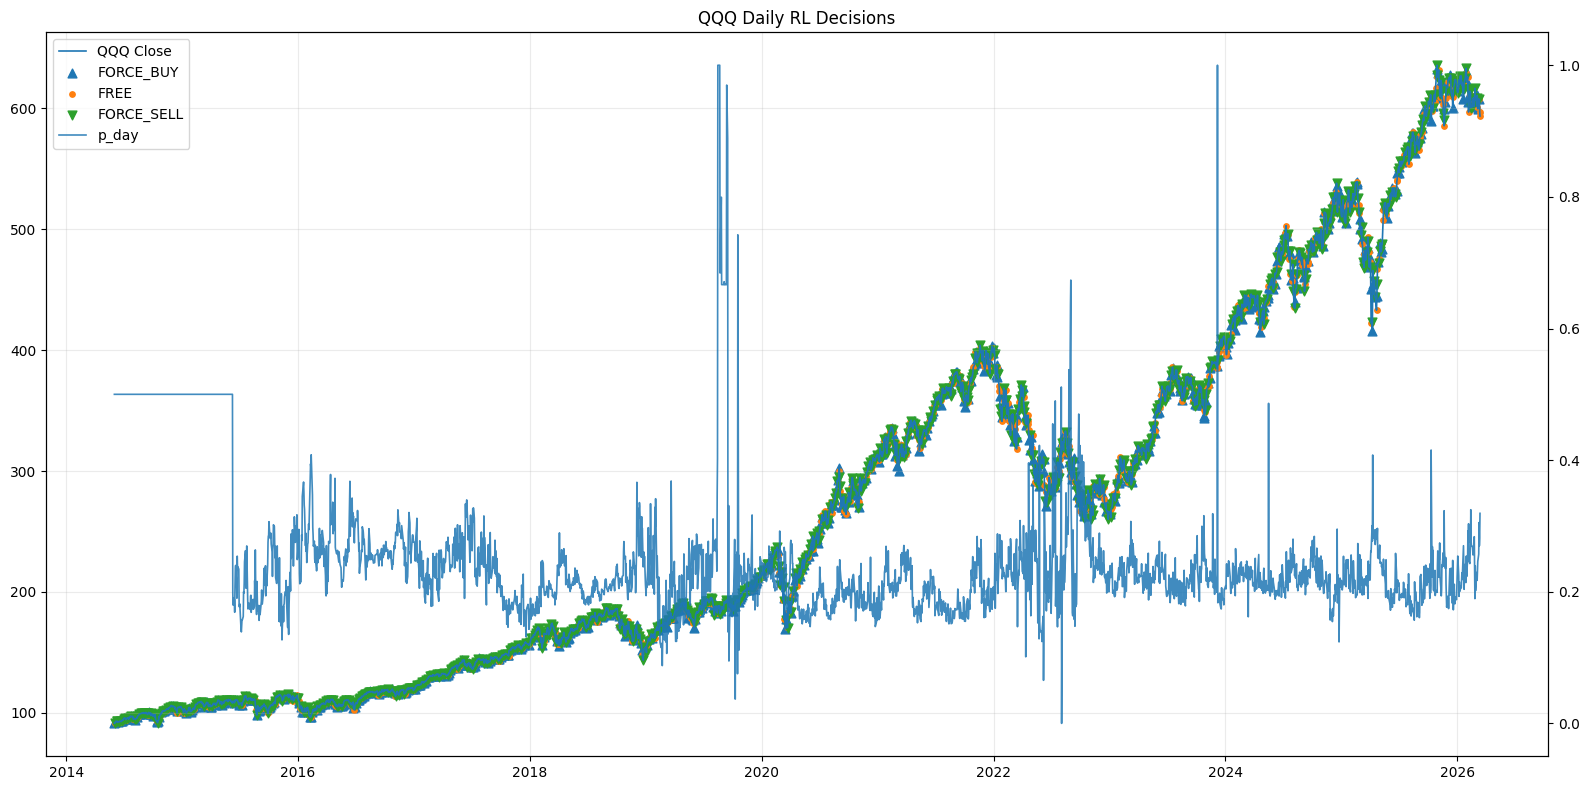

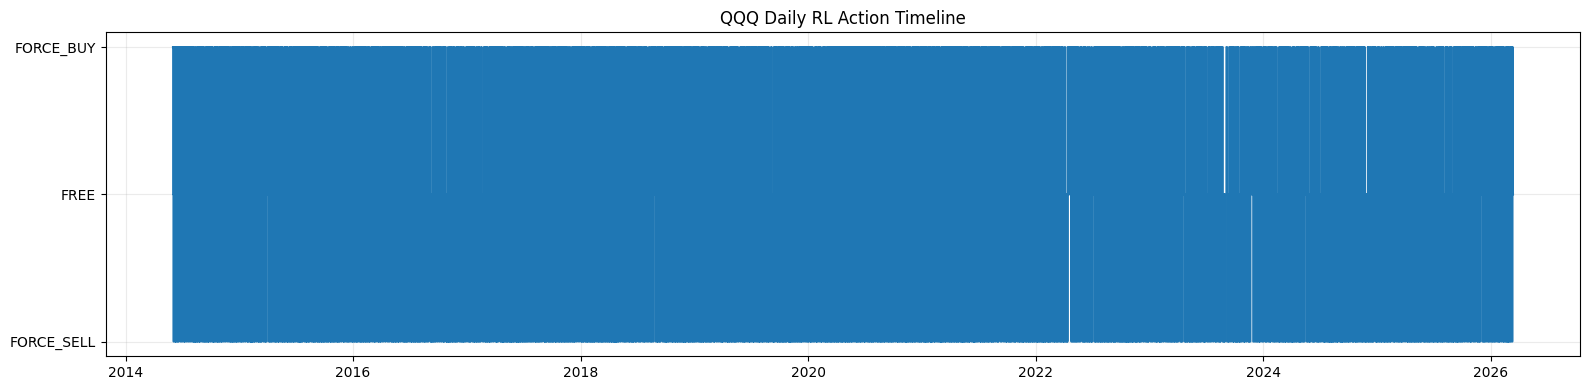

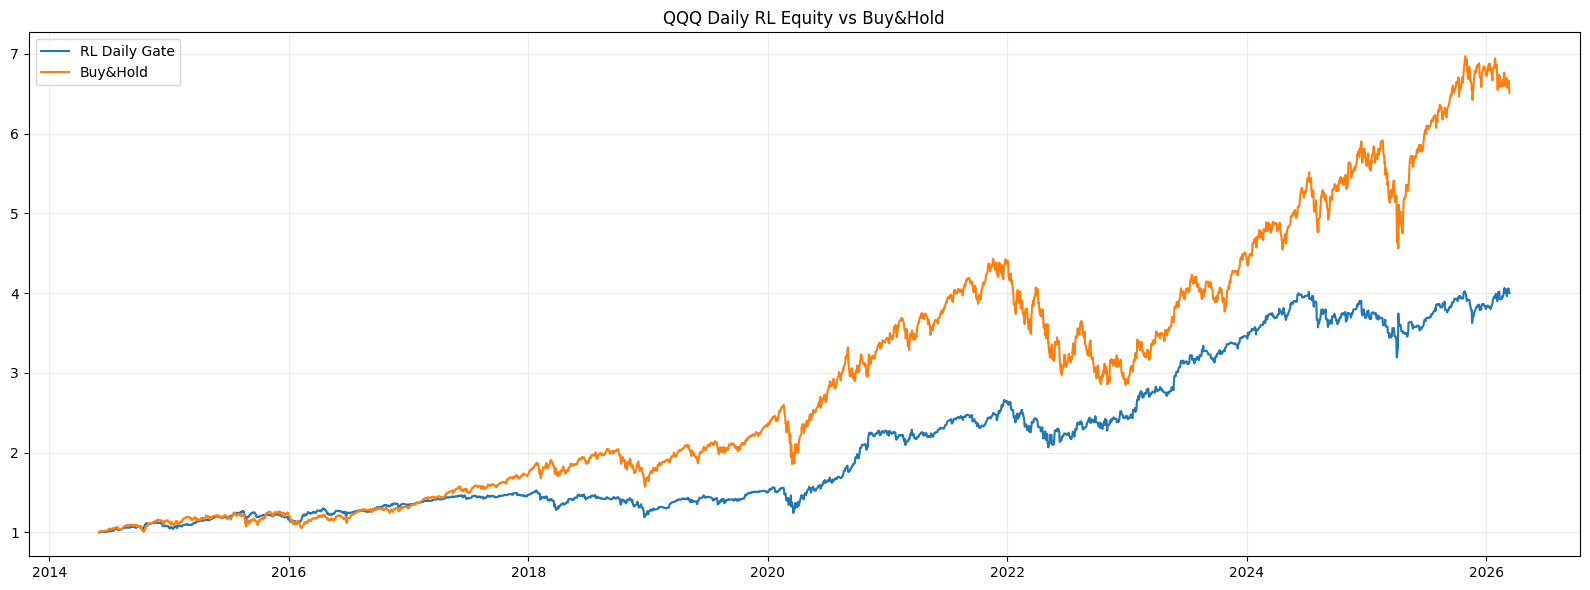

[SAVED] output_daily_rl_decisions_QQQ\QQQ_daily_rl_decisions.csv
[SAVED] output_daily_rl_decisions_QQQ\QQQ_daily_rl_close_p_actions.png
[SAVED] output_daily_rl_decisions_QQQ\QQQ_daily_rl_action_timeline.png
[SAVED] output_daily_rl_decisions_QQQ\QQQ_daily_rl_equity_vs_bh.png
[ROWS] 2964
           date  timestamp   close  next_open  next_close     p_day   dp_minK  \
2944 2026-02-13 2026-02-13  601.92    598.375      601.30  0.270608  0.027739   
2945 2026-02-17 2026-02-17  601.30    602.110      605.79  0.268226  0.025357   
2946 2026-02-18 2026-02-18  605.79    602.810      603.47  0.267834  0.009405   
2947 2026-02-19 2026-02-19  603.47    600.120      608.81  0.255940 -0.011164   
2948 2026-02-20 2026-02-20  608.81    606.605      601.41  0.266467  0.010528   
2949 2026-02-23 2026-02-23  601.41    602.400      607.87  0.283684  0.027744   
2950 2026-02-24 2026-02-24  607.87    611.070      616.68  0.239524 -0.016415   
2951 2026-02-25 2026-02-25  616.68    615.590      609.24  0.1895

In [3]:
# ============================================================
# DAILY-ONLY RL/BANDIT GATE MODEL
# - Train daily LR probability model
# - Use LinUCB bandit to choose each day's action:
#       FORCE_BUY / FREE / FORCE_SELL
# - Save daily decisions to CSV
# - Plot daily decisions and equity
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Any, List, Optional
from dataclasses import dataclass

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

# ---- your Chan imports ----
from sliding_window_chan import SlidingWindowChan
from ChanConfig import CChanConfig
from Common.CEnum import DATA_FIELD, KL_TYPE, AUTYPE
try:
    from Common.CEnum import DATA_SRC
except Exception:
    class DATA_SRC:
        CSV = "CSV"
from KLine.KLine_Unit import CKLine_Unit
from Common.CTime import CTime


# ============================================================
# 1) BASIC HELPERS
# ============================================================

def _safe_div(a, b, eps=1e-12):
    return a / (b + eps)

def _pick_col(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    lower_map = {c.lower(): c for c in cols}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


# ============================================================
# 2) DAILY CSV LOADER
# ============================================================

def load_daily_csv(daily_csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(daily_csv_path)

    ts_col = _pick_col(df, ["timestamp", "date", "datetime", "time"])
    if ts_col is None:
        ts_col = df.columns[0]

    df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
    df = df.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)
    df = df.rename(columns={ts_col: "timestamp"})

    open_col  = _pick_col(df, ["open", "Open", "o", "O"])
    high_col  = _pick_col(df, ["high", "High", "h", "H"])
    low_col   = _pick_col(df, ["low", "Low", "l", "L"])
    close_col = _pick_col(df, ["close", "Close", "adj_close", "Adj Close", "AdjClose", "c", "C"])
    vol_col   = _pick_col(df, ["volume", "Volume", "vol", "Vol", "v", "V"])

    if open_col is None or close_col is None:
        raise ValueError(f"CSV must contain open and close columns: {daily_csv_path}")
    if high_col is None:
        high_col = close_col
    if low_col is None:
        low_col = close_col

    df["_open"] = pd.to_numeric(df[open_col], errors="coerce").astype(float)
    df["_high"] = pd.to_numeric(df[high_col], errors="coerce").astype(float)
    df["_low"] = pd.to_numeric(df[low_col], errors="coerce").astype(float)
    df["_close"] = pd.to_numeric(df[close_col], errors="coerce").astype(float)
    df["_vol"] = pd.to_numeric(df[vol_col], errors="coerce").astype(float) if vol_col is not None else 0.0

    df = df.dropna(subset=["_open", "_high", "_low", "_close"]).reset_index(drop=True)
    df["ts_norm"] = df["timestamp"].dt.normalize()
    return df


# ============================================================
# 3) DAILY KLINE FEATURES
# ============================================================

KLINE_KEYS = [
    "ret1","ret_5","ret_10","ret_20","ret_40",
    "vol_5","vol_10","vol_20","vol_40",
    "atr_14","range_over_atr","close_pos","gap",
    "above_ma_20","above_ma_50","above_ma_100",
    "slope40",
]

def compute_kline_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy().sort_values("timestamp").reset_index(drop=True)

    o = d["_open"].astype(float)
    h = d["_high"].astype(float)
    l = d["_low"].astype(float)
    c = d["_close"].astype(float)

    prev_c = c.shift(1)
    d["ret1"] = (_safe_div(c, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    tr = pd.concat([(h-l).abs(), (h-prev_c).abs(), (l-prev_c).abs()], axis=1).max(axis=1)
    d["tr"] = tr.fillna(0.0)
    d["atr_14"] = d["tr"].rolling(14).mean().bfill().fillna(0.0)

    d["range_over_atr"] = _safe_div((h-l).abs(), d["atr_14"]).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    rng = (h - l).replace(0.0, np.nan)
    d["close_pos"] = ((c - l) / rng).replace([np.inf, -np.inf], np.nan).fillna(0.5)

    d["gap"] = (_safe_div(o, prev_c) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [5, 10, 20, 40]:
        d[f"ret_{w}"] = (_safe_div(c, c.shift(w)) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        d[f"vol_{w}"] = d["ret1"].rolling(w).std().replace([np.inf, -np.inf], np.nan).fillna(0.0)

    for w in [20, 50, 100]:
        ma = c.rolling(w).mean()
        d[f"above_ma_{w}"] = (_safe_div(c, ma) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    def _slope_log(x):
        x = np.asarray(x, dtype=float)
        x = np.log(np.maximum(x, 1e-12))
        t = np.arange(len(x), dtype=float)
        t = t - t.mean()
        x = x - x.mean()
        den = (t*t).sum()
        return 0.0 if den <= 0 else float((t*x).sum() / den)

    d["slope40"] = d["_close"].rolling(40).apply(_slope_log, raw=False).fillna(0.0)
    return d

def make_kline_dict(kline_row: pd.Series, prefix: str = "d_") -> Dict[str, float]:
    out = {}
    for k in KLINE_KEYS:
        val = kline_row[k] if k in kline_row.index else 0.0
        out[f"{prefix}{k}"] = float(val) if np.isfinite(val) else 0.0
    return out


# ============================================================
# 4) MACRO FEATURES
# ============================================================

def load_macro_features_from_folder(folder: str, files: Dict[str, str], start: str) -> pd.DataFrame:
    out = None
    for pref, fn in files.items():
        path = os.path.join(folder, fn)
        if not os.path.exists(path):
            raise FileNotFoundError(f"Macro file not found: {path}")

        dfm = load_daily_csv(path)
        dfm = dfm[dfm["timestamp"] >= pd.to_datetime(start)].copy().reset_index(drop=True)
        dfm_feat = compute_kline_features(dfm)

        dfm_feat[f"{pref}level"] = dfm_feat["_close"].astype(float)

        cols = ["ts_norm", f"{pref}level"] + KLINE_KEYS
        dfm_feat = dfm_feat[cols].copy()
        rename = {k: f"{pref}{k}" for k in KLINE_KEYS}
        dfm_feat = dfm_feat.rename(columns=rename)

        out = dfm_feat.copy() if out is None else out.merge(dfm_feat, on="ts_norm", how="outer")

    if out is None:
        out = pd.DataFrame(columns=["ts_norm"])

    if ("us10y_level" in out.columns) and ("us5y_level" in out.columns):
        out["yc_10y5y_level"] = out["us10y_level"] - out["us5y_level"]
        prev = out["yc_10y5y_level"].shift(1)
        out["yc_10y5y_ret1"] = (_safe_div(out["yc_10y5y_level"], prev) - 1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0)

        for w in [5, 10, 20, 40]:
            out[f"yc_10y5y_chg_{w}"] = (
                out["yc_10y5y_level"] - out["yc_10y5y_level"].shift(w)
            ).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    return out.sort_values("ts_norm").reset_index(drop=True)


# ============================================================
# 5) CHAN BUILDERS
# ============================================================

def to_ctime(ts) -> CTime:
    dt = pd.to_datetime(ts).to_pydatetime()
    try:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second, auto=False)
    except Exception:
        return CTime(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)

def build_klu(ts, o, h, l, c, v=0.0) -> CKLine_Unit:
    ct = to_ctime(ts)
    kl_dict = {
        DATA_FIELD.FIELD_TIME: ct,
        DATA_FIELD.FIELD_OPEN: float(o),
        DATA_FIELD.FIELD_HIGH: float(h),
        DATA_FIELD.FIELD_LOW:  float(l),
        DATA_FIELD.FIELD_CLOSE: float(c),
        DATA_FIELD.FIELD_VOLUME: float(v),
        "time": ct, "timestamp": ct, "datetime": ct,
        "open": float(o), "high": float(h), "low": float(l), "close": float(c),
        "volume": float(v),
    }
    klu = CKLine_Unit(kl_dict)
    try:
        klu.time = ct
    except Exception:
        pass
    return klu


# ============================================================
# 6) DAILY BSP HELPERS
# ============================================================

def normalize_bsp_row(r: Dict[str, Any]) -> Dict[str, Any]:
    rr = dict(r)
    if "direction" not in rr or rr["direction"] is None:
        if rr.get("is_buy", None) is not None:
            rr["direction"] = "buy" if bool(rr["is_buy"]) else "sell"
        else:
            rr["direction"] = "buy"
    rr["direction"] = str(rr["direction"]).lower()
    if "bsp_type" in rr and rr["bsp_type"] is not None:
        rr["bsp_type"] = str(rr["bsp_type"]).lower()
    else:
        rr["bsp_type"] = "?"
    return rr

def extract_bsp_rows_from_chan(chan_obj) -> List[Dict[str, Any]]:
    if hasattr(chan_obj, "export_new_historical_bsp_to_list"):
        out = chan_obj.export_new_historical_bsp_to_list()
        return out if out else []
    if hasattr(chan_obj, "export_new_bsp_to_list"):
        out = chan_obj.export_new_bsp_to_list()
        return out if out else []
    return []

def latest_bsp_dir_up_to(bsp_rows: List[Dict[str, Any]], ts: pd.Timestamp) -> Optional[str]:
    past = [r for r in bsp_rows if pd.to_datetime(r["timestamp"]) <= ts]
    if not past:
        return None
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    return str(past[-1].get("direction", "")).lower()

def make_daily_bsp_context(bsp_hist: List[Dict[str, Any]], cur_ts: pd.Timestamp, window_days: int = 60) -> Dict[str, float]:
    past = [r for r in bsp_hist if pd.to_datetime(r["timestamp"]) <= cur_ts]
    past = sorted(past, key=lambda x: pd.to_datetime(x["timestamp"]))
    if not past:
        return {
            "ctx_has_bsp": 0.0,
            "ctx_last_dir_buy": 0.0,
            "ctx_last_dir_sell": 0.0,
            "ctx_days_since_last_bsp": 999.0,
            "ctx_days_since_last_buy": 999.0,
            "ctx_days_since_last_sell": 999.0,
            "ctx_density_total": 0.0,
            "ctx_density_buy": 0.0,
            "ctx_density_sell": 0.0,
            "ctx_density_imb": 0.0,
        }

    last = past[-1]
    last_dir = str(last.get("direction", "")).lower()
    days_since_last = float((cur_ts.normalize() - pd.to_datetime(last["timestamp"]).normalize()).days)

    def _days_since(target: str) -> float:
        for r in reversed(past):
            if str(r.get("direction", "")).lower() == target:
                return float((cur_ts.normalize() - pd.to_datetime(r["timestamp"]).normalize()).days)
        return 999.0

    start = cur_ts.normalize() - pd.Timedelta(days=int(window_days))
    recent = [r for r in past if pd.to_datetime(r["timestamp"]).normalize() >= start]
    buy = sum(1 for r in recent if str(r.get("direction", "")).lower() == "buy")
    sell = sum(1 for r in recent if str(r.get("direction", "")).lower() == "sell")
    tot = max(1.0, float(buy + sell))

    return {
        "ctx_has_bsp": 1.0,
        "ctx_last_dir_buy": 1.0 if last_dir == "buy" else 0.0,
        "ctx_last_dir_sell": 1.0 if last_dir == "sell" else 0.0,
        "ctx_days_since_last_bsp": days_since_last,
        "ctx_days_since_last_buy": _days_since("buy"),
        "ctx_days_since_last_sell": _days_since("sell"),
        "ctx_density_total": float(len(recent)),
        "ctx_density_buy": float(buy),
        "ctx_density_sell": float(sell),
        "ctx_density_imb": float((sell - buy) / tot),
    }

def compute_chain_endpoints(bsp_rows: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    if not bsp_rows:
        return []
    bsps = sorted(bsp_rows, key=lambda r: pd.to_datetime(r["timestamp"]))
    ends = []
    cur_dir = str(bsps[0].get("direction", "")).lower()
    cur_end = bsps[0]
    cur_end_i = 0
    for i in range(1, len(bsps)):
        d = str(bsps[i].get("direction", "")).lower()
        if d == cur_dir:
            cur_end = bsps[i]
            cur_end_i = i
        else:
            ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
            cur_dir = d
            cur_end = bsps[i]
            cur_end_i = i
    ends.append({"end_ts": pd.to_datetime(cur_end["timestamp"]).normalize(), "end_dir": cur_dir, "end_i": cur_end_i})
    return ends

def regime_for_day_from_ends(day_norm: pd.Timestamp, ends: List[Dict[str, Any]]) -> str:
    if len(ends) < 2:
        return "unknown"
    for k in range(len(ends) - 1):
        a = ends[k]
        b = ends[k + 1]
        a_ts, a_dir = a["end_ts"], a["end_dir"]
        b_ts, b_dir = b["end_ts"], b["end_dir"]
        if (day_norm >= a_ts) and (day_norm <= b_ts):
            if a_dir == "buy" and b_dir == "sell":
                return "up"
            if a_dir == "sell" and b_dir == "buy":
                return "down"
    return "unknown"


# ============================================================
# 7) DAILY LABEL + LR MODEL
# ============================================================

def label_confirm_extreme(df_day_feat: pd.DataFrame, idx: int, N: int, base_dir: str) -> Optional[int]:
    if N <= 0:
        return None
    if idx + N >= len(df_day_feat):
        return None
    h0 = float(df_day_feat.loc[idx, "_high"])
    l0 = float(df_day_feat.loc[idx, "_low"])
    fut = df_day_feat.loc[idx+1:idx+N]
    if fut.empty:
        return None
    if base_dir == "sell":
        mx = float(fut["_high"].max())
        return 1 if mx < h0 else 0
    if base_dir == "buy":
        mn = float(fut["_low"].min())
        return 1 if mn > l0 else 0
    return None

def make_daily_features_one_model(
    kline_row: pd.Series,
    bsp_hist_up_to_day: List[Dict[str, Any]],
    p_val: float,
    dp_minK: float,
    dp_maxK: float,
    regime: str,
    base_dir: Optional[str],
    macro_cols: Optional[List[str]] = None,
) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    feats.update(make_kline_dict(kline_row, prefix="k_"))

    if macro_cols is not None:
        for c in macro_cols:
            if c in kline_row.index:
                val = kline_row[c]
                feats[c] = float(val) if np.isfinite(val) else 0.0

    ts = pd.to_datetime(kline_row["timestamp"])
    feats.update(make_daily_bsp_context(bsp_hist_up_to_day, ts, window_days=60))

    feats["p"] = float(p_val) if np.isfinite(p_val) else 0.0
    feats["dp_minK"] = float(dp_minK) if np.isfinite(dp_minK) else 0.0
    feats["dp_maxK"] = float(dp_maxK) if np.isfinite(dp_maxK) else 0.0

    rg = str(regime).lower()
    feats["rg_up"] = 1.0 if rg == "up" else 0.0
    feats["rg_down"] = 1.0 if rg == "down" else 0.0
    feats["rg_unknown"] = 1.0 if rg not in ("up", "down") else 0.0

    bd = str(base_dir).lower() if base_dir is not None else "none"
    feats["bd_buy"] = 1.0 if bd == "buy" else 0.0
    feats["bd_sell"] = 1.0 if bd == "sell" else 0.0
    feats["bd_none"] = 1.0 if bd not in ("buy", "sell") else 0.0

    return feats

def fit_prob_model_dicts(X_dicts: List[Dict[str, float]], y: np.ndarray):
    base = Pipeline([
        ("vec", DictVectorizer(sparse=True)),
        ("scaler", MaxAbsScaler()),
        ("lr", LogisticRegression(
            max_iter=8000,
            class_weight="balanced",
            solver="saga",
            C=0.5,
            n_jobs=-1
        ))
    ])
    uniq, counts = np.unique(y, return_counts=True)
    if len(uniq) < 2:
        raise ValueError("Only one class in y so far.")
    min_count = int(counts.min())

    if min_count >= 5:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        cal.fit(X_dicts, y)
        return cal
    elif min_count >= 3:
        cal = CalibratedClassifierCV(base, method="sigmoid", cv=2)
        cal.fit(X_dicts, y)
        return cal
    else:
        base.fit(X_dicts, y)
        return base

def predict_prob(model, X_dicts: List[Dict[str, float]]) -> np.ndarray:
    return model.predict_proba(X_dicts)[:, 1]


# ============================================================
# 8) DAILY BANDIT
# ============================================================

class BanditAction:
    FORCE_BUY = 0
    FREE = 1
    FORCE_SELL = 2

ACTION_TO_NAME = {
    BanditAction.FORCE_BUY: "FORCE_BUY",
    BanditAction.FREE: "FREE",
    BanditAction.FORCE_SELL: "FORCE_SELL",
}

class LinUCBBandit:
    def __init__(self, n_actions: int, n_features: int, alpha: float = 0.75, l2: float = 1.0):
        self.n_actions = int(n_actions)
        self.n_features = int(n_features)
        self.alpha = float(alpha)
        self.l2 = float(l2)

        self.A = [np.eye(self.n_features, dtype=float) * self.l2 for _ in range(self.n_actions)]
        self.b = [np.zeros(self.n_features, dtype=float) for _ in range(self.n_actions)]

    def select_action(self, x: np.ndarray) -> int:
        x = np.asarray(x, dtype=float).reshape(-1)
        scores = []
        for a in range(self.n_actions):
            A_inv = np.linalg.inv(self.A[a])
            theta = A_inv @ self.b[a]
            mean = float(theta @ x)
            bonus = self.alpha * float(np.sqrt(max(0.0, x @ A_inv @ x)))
            scores.append(mean + bonus)
        return int(np.argmax(scores))

    def update(self, action: int, x: np.ndarray, reward: float):
        x = np.asarray(x, dtype=float).reshape(-1)
        a = int(action)
        r = float(reward)
        self.A[a] += np.outer(x, x)
        self.b[a] += r * x


def make_bandit_state_from_daily_row(
    kline_row: pd.Series,
    bsp_hist_up_to_day: List[Dict[str, Any]],
    p_val: float,
    dp_minK: float,
    dp_maxK: float,
    regime: str,
    base_dir: Optional[str],
    macro_cols: Optional[List[str]],
    current_pos: int,
    current_gate: str,
    equity_rel: float,
    dd_rel: float,
) -> Dict[str, float]:
    feats = make_daily_features_one_model(
        kline_row=kline_row,
        bsp_hist_up_to_day=bsp_hist_up_to_day,
        p_val=p_val,
        dp_minK=dp_minK,
        dp_maxK=dp_maxK,
        regime=regime,
        base_dir=base_dir,
        macro_cols=macro_cols,
    )
    feats["cur_pos"] = float(current_pos)
    feats["cur_gate_force_buy"] = 1.0 if current_gate == "FORCE_BUY" else 0.0
    feats["cur_gate_free"] = 1.0 if current_gate == "FREE" else 0.0
    feats["cur_gate_force_sell"] = 1.0 if current_gate == "FORCE_SELL" else 0.0
    feats["equity_rel"] = float(equity_rel)
    feats["drawdown_rel"] = float(dd_rel)
    return feats


# ============================================================
# 9) DAILY-ONLY RUNNER
# ============================================================

def run_daily_rl_model_with_decision_output(
    daily_csv_path: str,
    code: str = "QQQ",
    daily_start: str = "2014-06-01",
    end_time: str = "2026-12-31",

    N_confirm: int = 5,
    min_labeled_days_to_train: int = 200,
    retrain_every_new_labels: int = 25,
    dp_lookback: int = 5,

    bandit_alpha: float = 0.75,
    bandit_l2: float = 1.0,

    initial_capital: float = 100000.0,
    fee_pct: float = 0.0,

    daily_chan_max_klines: int = 500,

    macro_files: dict | None = None,

    output_dir: str = "output_daily_rl_decisions",
    verbose: bool = True,
):
    os.makedirs(output_dir, exist_ok=True)

    if macro_files is None:
        macro_files = {
            "vix_":   "VIX.csv",
            "dxy_":   "DXY.csv",
            "us5y_":  "US5Y.csv",
            "us10y_": "US10Y.csv",
            "us30y_": "US30Y.csv",
            "xau_":   "XAU.csv",
            "nyxbt_": "NYXBT.csv",
        }

    # --------------------------------
    # Load data
    # --------------------------------
    df_day_raw = load_daily_csv(daily_csv_path)
    daily_s = pd.to_datetime(daily_start)
    end_t = pd.to_datetime(end_time)

    df_day = df_day_raw[(df_day_raw["timestamp"] >= daily_s) & (df_day_raw["timestamp"] <= end_t)].copy().reset_index(drop=True)
    if df_day.empty:
        raise ValueError("No daily bars in requested range.")

    df_day_feat = compute_kline_features(df_day)
    df_day_feat["ts_norm"] = pd.to_datetime(df_day_feat["timestamp"]).dt.normalize()

    macro_folder = os.path.dirname(os.path.abspath(daily_csv_path))
    macro_feat = load_macro_features_from_folder(macro_folder, macro_files, start=daily_start)
    df_day_feat = df_day_feat.merge(macro_feat, on="ts_norm", how="left").sort_values("timestamp").reset_index(drop=True)

    macro_cols = [
        c for c in df_day_feat.columns
        if (
            c.startswith("vix_")
            or c.startswith("dxy_")
            or c.startswith("us5y_")
            or c.startswith("us10y_")
            or c.startswith("us30y_")
            or c.startswith("xau_")
            or c.startswith("nyxbt_")
            or c.startswith("yc_")
            or c.startswith("10y2ys_")
            or c.startswith("us2y_")
            or c.startswith("spy_")
            or c.startswith("qqq_")
            or c.startswith("ixic_")
            or c.startswith("ndx_")
            or c.startswith("dji_")
            or c.startswith("vxn_")
            or c.startswith("vvix_")
            or c.startswith("vix3m_")
            or c.startswith("rvx_")
            or c.startswith("rut_")
            or c.startswith("spgsci_")
        )
    ]

    # --------------------------------
    # Chan config
    # --------------------------------
    config = CChanConfig({
        "cal_demark": True,
        "cal_kdj": True,
        "cal_dmi": True,
        "cal_rsi": True,
        "cal_rsl": True,
        "cal_demand_index": True,
        "cal_adline": True,
        "cal_bb_vals": True,
        "cal_kc_vals": True,
        "cal_starc_vals": True,
        "bi_strict": True,
        "trigger_step": True,
        "skip_step": 0,
        "divergence_rate": float("inf"),
        "bsp2_follow_1": True,
        "bsp3_follow_1": False,
        "min_zs_cnt": 0,
        "bs1_peak": False,
        "macd_algo": "peak",
        "bs_type": "1,2,3a,1p,2s,3b",
        "print_warning": False,
        "zs_algo": "normal",
    })

    daily_chan = SlidingWindowChan(
        code=code,
        begin_time=None,
        end_time=None,
        data_src=getattr(DATA_SRC, "CSV", "CSV"),
        lv_list=[KL_TYPE.K_DAY],
        config=config,
        autype=AUTYPE.QFQ,
        max_klines=int(daily_chan_max_klines),
    )

    # --------------------------------
    # Daily LR state
    # --------------------------------
    bsp_rows_daily = []
    seen_bsp_daily = set()

    X_days = []
    y_days = []
    pending_idx = []

    model = None
    trained_n = 0
    new_labels = 0

    p_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_minK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    dp_vs_maxK_series = np.full(len(df_day_feat), np.nan, dtype=float)
    p_by_day = {}

    def maybe_train_daily():
        nonlocal model, trained_n, new_labels
        if len(y_days) < int(min_labeled_days_to_train):
            return
        if model is None or new_labels >= int(retrain_every_new_labels):
            y = np.asarray(y_days, dtype=int)
            if len(np.unique(y)) < 2:
                return
            model = fit_prob_model_dicts(X_days, y)
            trained_n = len(y)
            new_labels = 0
            if verbose:
                print(f"[TRAIN][DAILY-PROB] n={len(y)} pos={int(y.sum())} ({y.mean():.2%})")

    # --------------------------------
    # First pass: train daily LR p_day
    # --------------------------------
    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        daily_chan.process_new_kline(build_klu(ts, r["_open"], r["_high"], r["_low"], r["_close"], r["_vol"]))

        new_bsp = extract_bsp_rows_from_chan(daily_chan)
        if new_bsp:
            for rr0 in new_bsp:
                rr = normalize_bsp_row(dict(rr0))
                rr.setdefault("timestamp", ts)
                key = (pd.to_datetime(rr["timestamp"]).strftime("%Y-%m-%d"), rr["direction"], rr.get("bsp_type", "?"))
                if key in seen_bsp_daily:
                    continue
                seen_bsp_daily.add(key)
                bsp_rows_daily.append(rr)

        ends = compute_chain_endpoints(bsp_rows_daily)
        regime = regime_for_day_from_ends(day, ends)
        base_dir_today = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        p_val = np.nan
        if model is not None:
            bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
            feat_i = make_daily_features_one_model(
                kline_row=r,
                bsp_hist_up_to_day=bsp_hist,
                p_val=0.0,
                dp_minK=0.0,
                dp_maxK=0.0,
                regime=regime,
                base_dir=base_dir_today,
                macro_cols=macro_cols,
            )
            p_val = float(predict_prob(model, [feat_i])[0])
            p_series[i] = p_val
            p_by_day[day] = p_val

        lb = int(dp_lookback)
        p_minK = np.nan
        p_maxK = np.nan
        if lb > 0 and i >= 1 and np.isfinite(p_val):
            start = max(0, i - lb)
            prev = pd.Series(p_series[start:i]).dropna()
            if len(prev) > 0:
                p_minK = float(prev.min())
                p_maxK = float(prev.max())

        dp_vs_minK = (p_val - p_minK) if (np.isfinite(p_val) and np.isfinite(p_minK)) else np.nan
        dp_vs_maxK = (p_val - p_maxK) if (np.isfinite(p_val) and np.isfinite(p_maxK)) else np.nan
        dp_vs_minK_series[i] = dp_vs_minK
        dp_vs_maxK_series[i] = dp_vs_maxK

        pending_idx.append(i)
        while pending_idx and i >= pending_idx[0] + int(N_confirm):
            j = pending_idx.pop(0)
            t0 = pd.to_datetime(df_day_feat.loc[j, "timestamp"])
            base_dir_j = latest_bsp_dir_up_to(bsp_rows_daily, t0)
            if base_dir_j not in ("buy", "sell"):
                continue

            y = label_confirm_extreme(df_day_feat, j, int(N_confirm), base_dir_j)
            if y is None:
                continue

            ends_j = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0])
            regime_j = regime_for_day_from_ends(t0.normalize(), ends_j)

            bsp_hist_j = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= t0]
            feat_j = make_daily_features_one_model(
                kline_row=df_day_feat.loc[j],
                bsp_hist_up_to_day=bsp_hist_j,
                p_val=float(p_series[j]) if np.isfinite(p_series[j]) else 0.0,
                dp_minK=float(dp_vs_minK_series[j]) if np.isfinite(dp_vs_minK_series[j]) else 0.0,
                dp_maxK=float(dp_vs_maxK_series[j]) if np.isfinite(dp_vs_maxK_series[j]) else 0.0,
                regime=regime_j,
                base_dir=base_dir_j,
                macro_cols=macro_cols,
            )

            X_days.append(feat_j)
            y_days.append(int(y))
            new_labels += 1

        maybe_train_daily()

    # --------------------------------
    # Build bandit vectorizer
    # --------------------------------
    vec_fit_list = []
    for i in range(len(df_day_feat)):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        ends = compute_chain_endpoints([b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts])
        regime = regime_for_day_from_ends(day, ends)
        base_dir = latest_bsp_dir_up_to(bsp_rows_daily, ts)
        bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]

        dummy = make_bandit_state_from_daily_row(
            kline_row=r,
            bsp_hist_up_to_day=bsp_hist,
            p_val=float(p_series[i]) if np.isfinite(p_series[i]) else 0.5,
            dp_minK=float(dp_vs_minK_series[i]) if np.isfinite(dp_vs_minK_series[i]) else 0.0,
            dp_maxK=float(dp_vs_maxK_series[i]) if np.isfinite(dp_vs_maxK_series[i]) else 0.0,
            regime=regime,
            base_dir=base_dir,
            macro_cols=macro_cols,
            current_pos=0,
            current_gate="FREE",
            equity_rel=1.0,
            dd_rel=0.0,
        )
        vec_fit_list.append(dummy)

    bandit_vec = DictVectorizer(sparse=False)
    bandit_vec.fit(vec_fit_list)

    bandit = LinUCBBandit(
        n_actions=3,
        n_features=len(bandit_vec.feature_names_),
        alpha=bandit_alpha,
        l2=bandit_l2,
    )

    # --------------------------------
    # Run daily RL decisions
    # --------------------------------
    decisions = []
    pos = 1
    cur_gate = "FREE"
    equity = float(initial_capital)
    equity_peak = float(initial_capital)

    # start fully invested for equity bookkeeping
    qty = initial_capital / float(df_day_feat.loc[0, "_close"])
    cash = 0.0

    for i in range(len(df_day_feat) - 1):
        r = df_day_feat.loc[i]
        ts = pd.to_datetime(r["timestamp"])
        day = ts.normalize()

        bsp_hist = [b for b in bsp_rows_daily if pd.to_datetime(b["timestamp"]) <= ts]
        ends = compute_chain_endpoints(bsp_hist)
        regime = regime_for_day_from_ends(day, ends)
        base_dir = latest_bsp_dir_up_to(bsp_rows_daily, ts)

        p_day = float(p_series[i]) if np.isfinite(p_series[i]) else 0.5
        dp_min = float(dp_vs_minK_series[i]) if np.isfinite(dp_vs_minK_series[i]) else 0.0
        dp_max = float(dp_vs_maxK_series[i]) if np.isfinite(dp_vs_maxK_series[i]) else 0.0

        close_i = float(df_day_feat.loc[i, "_close"])
        mark_eq = cash + qty * close_i
        equity_peak = max(equity_peak, mark_eq)
        dd_rel = 0.0 if equity_peak <= 0 else max(0.0, (equity_peak - mark_eq) / equity_peak)

        state_dict = make_bandit_state_from_daily_row(
            kline_row=r,
            bsp_hist_up_to_day=bsp_hist,
            p_val=p_day,
            dp_minK=dp_min,
            dp_maxK=dp_max,
            regime=regime,
            base_dir=base_dir,
            macro_cols=macro_cols,
            current_pos=pos,
            current_gate=cur_gate,
            equity_rel=mark_eq / max(initial_capital, 1e-12),
            dd_rel=dd_rel,
        )
        x = bandit_vec.transform([state_dict])[0]
        action = bandit.select_action(x)
        action_name = ACTION_TO_NAME[action]

        next_open = float(df_day_feat.loc[i + 1, "_open"])
        next_close = float(df_day_feat.loc[i + 1, "_close"])

        # execute action at next open
        exec_px = next_open
        if action_name == "FORCE_BUY" and pos == 0:
            notional = cash
            fee = notional * fee_pct
            spend = notional + fee
            if spend > cash:
                notional = cash / (1.0 + fee_pct)
                fee = notional * fee_pct
                spend = notional + fee
            if notional > 0:
                qty = notional / exec_px
                cash -= spend
                pos = 1

        elif action_name == "FORCE_SELL" and pos == 1:
            notional = qty * exec_px
            fee = notional * fee_pct
            cash += (notional - fee)
            qty = 0.0
            pos = 0

        # reward proxy
        gross_ret = (next_close / max(next_open, 1e-12)) - 1.0
        if action_name == "FORCE_BUY":
            reward = gross_ret
        elif action_name == "FORCE_SELL":
            reward = 0.0
        else:
            reward = 0.5 * gross_ret

        bandit.update(action, x, reward)

        end_eq = cash + qty * next_close

        decisions.append({
            "date": day,
            "timestamp": ts,
            "close": close_i,
            "next_open": next_open,
            "next_close": next_close,
            "p_day": p_day,
            "dp_minK": dp_min,
            "dp_maxK": dp_max,
            "regime": regime,
            "base_dir": base_dir if base_dir is not None else "none",
            "action": action_name,
            "action_id": action,
            "position_after_action": pos,
            "equity_before": mark_eq,
            "equity_after": end_eq,
            "reward": reward,
            "drawdown_rel": dd_rel,
        })

        cur_gate = action_name
        equity = end_eq
        equity_peak = max(equity_peak, equity)

    decisions_df = pd.DataFrame(decisions)

    # last row filler
    if len(df_day_feat) > 0:
        last_ts = pd.to_datetime(df_day_feat.loc[len(df_day_feat)-1, "timestamp"])
        last_day = last_ts.normalize()
        if last_day not in set(decisions_df["date"]) if len(decisions_df) else True:
            decisions_df = pd.concat([
                decisions_df,
                pd.DataFrame([{
                    "date": last_day,
                    "timestamp": last_ts,
                    "close": float(df_day_feat.loc[len(df_day_feat)-1, "_close"]),
                    "next_open": np.nan,
                    "next_close": np.nan,
                    "p_day": float(p_series[len(df_day_feat)-1]) if np.isfinite(p_series[len(df_day_feat)-1]) else np.nan,
                    "dp_minK": float(dp_vs_minK_series[len(df_day_feat)-1]) if np.isfinite(dp_vs_minK_series[len(df_day_feat)-1]) else np.nan,
                    "dp_maxK": float(dp_vs_maxK_series[len(df_day_feat)-1]) if np.isfinite(dp_vs_maxK_series[len(df_day_feat)-1]) else np.nan,
                    "regime": "unknown",
                    "base_dir": "none",
                    "action": cur_gate,
                    "action_id": np.nan,
                    "position_after_action": pos,
                    "equity_before": equity,
                    "equity_after": equity,
                    "reward": np.nan,
                    "drawdown_rel": 0.0,
                }])
            ], ignore_index=True)

    decisions_df = decisions_df.sort_values("date").reset_index(drop=True)

    # buy and hold
    first_close = float(df_day_feat.loc[0, "_close"])
    bh_equity = initial_capital * (df_day_feat["_close"].astype(float) / max(first_close, 1e-12))
    bh_df = pd.DataFrame({
        "date": pd.to_datetime(df_day_feat["timestamp"]).dt.normalize(),
        "bh_equity": bh_equity.values,
    })

    decisions_df = decisions_df.merge(bh_df, on="date", how="left")

    # --------------------------------
    # Save files
    # --------------------------------
    decisions_csv = os.path.join(output_dir, f"{code}_daily_rl_decisions.csv")
    decisions_df.to_csv(decisions_csv, index=False)

    # --------------------------------
    # Plots
    # --------------------------------
    # 1) close + p_day + action markers
    plot1 = os.path.join(output_dir, f"{code}_daily_rl_close_p_actions.png")
    plt.figure(figsize=(16, 8))
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    ax1.plot(decisions_df["date"], decisions_df["close"], label=f"{code} Close", linewidth=1.2)
    ax2.plot(decisions_df["date"], decisions_df["p_day"], label="p_day", linewidth=1.2, alpha=0.85)

    buy_df = decisions_df[decisions_df["action"] == "FORCE_BUY"]
    free_df = decisions_df[decisions_df["action"] == "FREE"]
    sell_df = decisions_df[decisions_df["action"] == "FORCE_SELL"]

    if len(buy_df):
        ax1.scatter(buy_df["date"], buy_df["close"], marker="^", s=40, label="FORCE_BUY")
    if len(free_df):
        ax1.scatter(free_df["date"], free_df["close"], marker="o", s=15, label="FREE")
    if len(sell_df):
        ax1.scatter(sell_df["date"], sell_df["close"], marker="v", s=40, label="FORCE_SELL")

    ax1.set_title(f"{code} Daily RL Decisions")
    ax1.grid(True, alpha=0.25)

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    plt.tight_layout()
    plt.savefig(plot1, dpi=180)
    plt.show()

    # 2) action timeline
    plot2 = os.path.join(output_dir, f"{code}_daily_rl_action_timeline.png")
    action_y = decisions_df["action"].map({
        "FORCE_SELL": -1,
        "FREE": 0,
        "FORCE_BUY": 1,
    }).astype(float)

    plt.figure(figsize=(16, 4))
    plt.step(decisions_df["date"], action_y, where="post")
    plt.yticks([-1, 0, 1], ["FORCE_SELL", "FREE", "FORCE_BUY"])
    plt.title(f"{code} Daily RL Action Timeline")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(plot2, dpi=180)
    plt.show()

    # 3) equity vs buy and hold
    plot3 = os.path.join(output_dir, f"{code}_daily_rl_equity_vs_bh.png")
    plt.figure(figsize=(16, 6))
    plt.plot(decisions_df["date"], decisions_df["equity_after"] / decisions_df["equity_after"].iloc[0], label="RL Daily Gate")
    plt.plot(decisions_df["date"], decisions_df["bh_equity"] / decisions_df["bh_equity"].iloc[0], label="Buy&Hold")
    plt.title(f"{code} Daily RL Equity vs Buy&Hold")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(plot3, dpi=180)
    plt.show()

    if verbose:
        print(f"[SAVED] {decisions_csv}")
        print(f"[SAVED] {plot1}")
        print(f"[SAVED] {plot2}")
        print(f"[SAVED] {plot3}")
        print(f"[ROWS] {len(decisions_df)}")

    return {
        "decisions_df": decisions_df,
        "output_dir": output_dir,
        "decisions_csv": decisions_csv,
        "plots": [plot1, plot2, plot3],
    }


# ============================================================
# EXAMPLE RUN
# ============================================================
res = run_daily_rl_model_with_decision_output(
    daily_csv_path="DataAPI/data/QQQ_DAY.csv",
    code="QQQ",
    daily_start="2014-06-01",
    end_time="2026-12-31",

    N_confirm=5,
    min_labeled_days_to_train=200,
    retrain_every_new_labels=25,
    dp_lookback=5,

    bandit_alpha=0.75,
    bandit_l2=1.0,

    initial_capital=100000.0,
    fee_pct=0.0,

    daily_chan_max_klines=500,

    macro_files={
        "vix_":   "VIX.csv",
        "dxy_":   "DXY.csv",
        "us5y_":  "US5Y.csv",
        "us10y_": "US10Y.csv",
        "us30y_": "US30Y.csv",
        "xau_":   "XAU.csv",
        "nyxbt_": "NYXBT.csv",
        "10y2ys_": "10Y2YS.csv",
        "us2y_": "US2Y.csv",
        "spgsci_": "SPGSCI.csv",
        "spy_": "SPY_DAY.csv",
        "qqq_": "QQQ_DAY.csv",
        "rut_": "RUT.csv",
        "vvix_": "VVIX.csv",
        "vix3m_": "VIX3M.csv",
        "vxn_": "VXN.csv",
        "rvx_": "RVX.csv",
        "ixic_": "IXIC.csv",
        "ndx_": "NDX.csv",
        "dji_": "DJI.csv",
    },

    output_dir="output_daily_rl_decisions_QQQ",
    verbose=True,
)

print(res["decisions_df"].tail(20))